<a href="https://colab.research.google.com/github/ThandiweM/msc-ai-thesis/blob/feature%2Fed5005-data-imbalance/ed5005_etivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Student name: Thandiwe Feziwe Mangana
#### Student ID: 24325104

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install polars
!pip install fg-data-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.3/400.3 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.4 MB/s eta 0:00:00


In [ ]:
import polars as pl
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_recall_fscore_support
from sklearn import set_config
import pickle
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.stats import loguniform, randint, uniform
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.ensemble import ExtraTreesClassifier
pd.set_option('display.max_columns', None)
from pathlib import Path
from data_profiling import ProfileReport
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import learning_curve
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import shap
from sklearn.model_selection import StratifiedGroupKFold

###Data loading and sampling

In [ ]:
# @title
class FeatureTaxanomy:
    """
    Contains features' schema

    """

    FEATURE_MAP = {
    'length_to':'length_to_address',
    'is_contract_creation':'coming_from_contract',
    'length_from':'length_from_address',
    'is_same_address':'from_is_same_as_to_address',
    'duration_seconds':'duration',
    'gas_used.gas_used_summation':'gas_used_summation',
    'gas_used.gas_used_average':'gas_used_average',
    'gas_used.gas_used_median':'gas_used_median',
    'gas_used.gas_used_standard_deviation':'gas_used_standard_deviation',
    'gas_used.gas_used_maximum_val':'gas_used_maximum_val',
    'gas_used.gas_used_minimum_val':'gas_used_minimum_val',
    'gas_used.gas_used_variance':'gas_used_variance',
    'gas_used.gas_used_range_value':'gas_used_range_value',
    'gas_used.gas_used_skewness':'gas_used_skewness',
    'gas_used.gas_used_mode':'gas_used_mode',
    'gas_used.gas_used_coefficient_of_variation':'gas_used_coefficient_of_variation',
    'gas_prices.gas_prices_summation':'gas_prices_summation',
    'gas_prices.gas_prices_average':'gas_prices_average',
    'gas_prices.gas_prices_median':'gas_prices_median',
    'gas_prices.gas_prices_standard_deviation':'gas_prices_standard_deviation',
    'gas_prices.gas_prices_maximum_val':'gas_prices_maximum_val',
    'gas_prices.gas_prices_minimum_val':'gas_prices_minimum_val',
    'gas_prices.gas_prices_variance':'gas_prices_variance',
    'gas_prices.gas_prices_range_value':'gas_prices_range_value',
    'gas_prices.gas_prices_skewness':'gas_prices_skewness',
    'gas_prices.gas_prices_mode':'gas_prices_mode',
    'gas_prices.gas_prices_coefficient_of_variation':'gas_prices_coefficient_of_variation',
    'cumulativeGasUsed.cumulativeGasUsed_summation':'cumulativeGasUsed_summation',
    'cumulativeGasUsed.cumulativeGasUsed_average':'cumulativeGasUsed_average',
    'cumulativeGasUsed.cumulativeGasUsed_median':'cumulativeGasUsed_median',
    'cumulativeGasUsed.cumulativeGasUsed_standard_deviation':'cumulativeGasUsed_standard_deviation',
    'cumulativeGasUsed.cumulativeGasUsed_maximum_val':'cumulativeGasUsed_maximum_val',
    'cumulativeGasUsed.cumulativeGasUsed_minimum_val':'cumulativeGasUsed_minimum_val',
    'cumulativeGasUsed.cumulativeGasUsed_variance':'cumulativeGasUsed_variance',
    'cumulativeGasUsed.cumulativeGasUsed_range_value':'cumulativeGasUsed_range_value',
    'cumulativeGasUsed.cumulativeGasUsed_skewness':'cumulativeGasUsed_skewness',
    'cumulativeGasUsed.cumulativeGasUsed_mode':'cumulativeGasUsed_mode',
    'cumulativeGasUsed.cumulativeGasUsed_coefficient_of_variation':'cumulativeGasUsed_coefficient_of_variation',
    'values.values_summation':'values_summation',
    'values.values_average':'values_average',
    'values.values_median':'values_median',
    'values.values_standard_deviation':'values_standard_deviation',
    'values.values_maximum_val':'values_maximum_val',
    'values.values_minimum_val':'values_minimum_val',
    'values.values_variance':'values_variance',
    'values.values_range_value':'values_range_value',
    'values.values_skewness':'values_skewness',
    'values.values_mode':'values_mode',
    'values.values_coefficient_of_variation':'values_coefficient_of_variation',
    'nonce.nonce_summation':'nonce_summation',
    'nonce.nonce_average':'nonce_average',
    'nonce.nonce_median':'nonce_median',
    'nonce.nonce_standard_deviation':'nonce_standard_deviation',
    'nonce.nonce_maximum_val':'nonce_maximum_val',
    'nonce.nonce_minimum_val':'nonce_minimum_val',
    'nonce.nonce_variance':'nonce_variance',
    'nonce.nonce_range_value':'nonce_range_value',
    'nonce.nonce_skewness':'nonce_skewness',
    'nonce.nonce_mode':'nonce_mode',
    'nonce.nonce_coefficient_of_variation':'nonce_coefficient_of_variation'}

    FEATURE_TO_KEEP = [
    'length_transaction_hash',
    'length_to_address',
    'coming_from_contract',
    'status',
    'log_removed',
    #'block_number',
    'gas_used',
    'length_from_address',
    'index',
    'gas_efficiency',
    'value',
    'chain_id',
    'message',
    'total_gas_cost',
    'gas_per_log_event',
    'log_index',
    'event_activity_flag',
    'normalized_token_transfer',
    'effective_gas_price',
    'cumulative_gas_used',
    'from_is_same_as_to_address',
    'gas_price_ratio',
    'token_transfer_amount',
    'length_log',
    'Error!',
    'log_count',
    'num_transaction',
    'duration',
    'number_of_errors',
    'error_rate',
    'gas_used_summation',
    'gas_used_average',
    'gas_used_median',
    'gas_used_standard_deviation',
    'gas_used_maximum_val',
    'gas_used_minimum_val',
    'gas_used_variance',
    'gas_used_range_value',
    'gas_used_skewness',
    'gas_used_mode',
    'gas_used_coefficient_of_variation',
    'gas_prices_summation',
    'gas_prices_average',
    'gas_prices_median',
    'gas_prices_standard_deviation',
    'gas_prices_maximum_val',
    'gas_prices_minimum_val',
    'gas_prices_variance',
    'gas_prices_range_value',
    'gas_prices_skewness',
    'gas_prices_mode',
    'gas_prices_coefficient_of_variation',
    'cumulativeGasUsed_summation',
    'cumulativeGasUsed_average',
    'cumulativeGasUsed_median',
    'cumulativeGasUsed_standard_deviation',
    'cumulativeGasUsed_maximum_val',
    'cumulativeGasUsed_minimum_val',
    'cumulativeGasUsed_variance',
    'cumulativeGasUsed_range_value',
    'cumulativeGasUsed_skewness',
    'cumulativeGasUsed_mode',
    'cumulativeGasUsed_coefficient_of_variation',
    'values_summation',
    'values_average',
    'values_median',
    'values_standard_deviation',
    'values_maximum_val',
    'values_minimum_val',
    'values_variance',
    'values_range_value',
    'values_skewness',
    'values_mode',
    'values_coefficient_of_variation',
    'nonce_summation',
    'nonce_average',
    'nonce_median',
    'nonce_standard_deviation',
    'nonce_maximum_val',
    'nonce_minimum_val',
    'nonce_variance',
    'nonce_range_value',
    'nonce_skewness',
    'nonce_mode',
    'nonce_coefficient_of_variation',
    'number_of_from_address',
    'number_of_unique_from_address',
    'number_of_to_address',
    'number_of_unique_to_address'
    ]

In [ ]:
# @title

class DataIngestion:
    """
    Contains functions for matrix manipulation namely:
    a : multiplication
    b : transpose
    c : inverse

    """

    base_path = ''
    fraud_path = ''
    legitimate_path = ''
    fraud_parquet_path = ''
    legitimate_parquet_path = ''

    def __init__(self, base_path, fraud_filename, legitimate_filename):

        """
        Constructor for the DataIngester class.
        It takes the parameters and generates file paths.

        Parameters
        ----------
        base_path : string
            The path to the folder in which all the data is stored.
        fraud_filename : string
            The name of the file containing the fraud data.
        legitimate_filename : string
            The name of the file containing the legitimate data.

        """
        self.base_path = base_path
        self.fraud_path = self.base_path + fraud_filename
        self.legitimate_path = self.base_path + legitimate_filename

        fraud_parquet_filename = 'fraud.parquet'
        self.fraud_parquet_path = self.base_path + fraud_parquet_filename
        legitimate_parquet_filename = 'legitimate.parquet'
        self.legitimate_parquet_path = self.base_path + legitimate_parquet_filename

    def ingest_data(self):

        """
        Ingests the raw data from the csv files and saves it as parquet files.

        This is to optimise for large csv files

        Parameters
        ----------
        None

        Returns
        -------
        tuple
            The paths to the generated and saved parquet files.

        """
        q_fraud = pl.scan_csv(self.fraud_path,
                       infer_schema_length=10000,
                       ignore_errors=True,
                       schema_overrides={'token_transfer_amount':pl.Float64})

        q_fraud.sink_parquet(self.fraud_parquet_path)

        q_legitimate = pl.scan_csv(self.legitimate_path,
                       infer_schema_length=10000,
                       ignore_errors=True,
                       schema_overrides={'token_transfer_amount':pl.Float64})

        q_legitimate.sink_parquet(self.legitimate_parquet_path)

        return self.fraud_parquet_path, self.legitimate_parquet_path

    def extract_subset(self, fraud_parquet_path, legitimate_parquet_path, n_samples=20000):

        """
        Extracts a subset of the data from the parquet files.
        It combines the fraud and legitimate data and saves it as a parquet file.

        Parameters
        ----------
        n_samples : int
            The number of samples to extract from each dataset.
            The default is 20000.
        fraud_parquet_path : string
            The path to the parquet file containing the fraud data.
        legitimate_parquet_path : string
            The path to the parquet file containing the legitimate data.

        Returns
        -------
        string
            The path to the generated and saved parquet file.

        """

        lazy_legitimate = pl.scan_parquet(legitimate_parquet_path)
        lazy_fraud = pl.scan_parquet(fraud_parquet_path)

        #Creating one dataset and extracting a sample of 20 000
        legitimate_count = lazy_legitimate.select(pl.len()).collect().item()
        fraud_count = lazy_fraud.select(pl.len()).collect().item()

        print(f"Normal transactions: {legitimate_count}")
        print(f"Fraud transactions: {fraud_count}")

        #Calculating the target for n_samples rows
        total_sample = n_samples
        fraud_ratio = fraud_count / (legitimate_count + fraud_count)
        target_fraud = int(total_sample * fraud_ratio)
        target_legitimate = total_sample - target_fraud

        #List of columns that have a mismatch
        mismatch_cols = ['erc_721_TokenAddress', 'erc_721_TokenName', 'erc_721_TokenSymbol']

        #Standardize both LazyFrames to String
        lazy_fraud = lazy_fraud.with_columns([
            pl.col(c).cast(pl.String) for c in mismatch_cols
        ])

        lazy_legitimate = lazy_legitimate.with_columns([
            pl.col(c).cast(pl.String) for c in mismatch_cols
        ])

        #Sampling from LazyFrames
        df_fraud = lazy_fraud.collect().sample(n=target_fraud, shuffle=True, seed=42)
        df_legitimate = lazy_legitimate.collect().sample(n=target_legitimate, shuffle=True, seed=42)

        #Concatenating and shuffling
        df_final = pl.concat([df_fraud, df_legitimate]).sample(fraction=1.0, shuffle=True, seed=42)

        #Save as parquet
        df_final.write_parquet(self.base_path + 'dataset.parquet')

        #Save as csv
        df_final.write_csv(self.base_path + 'dataset.csv')
        return self.base_path + 'dataset.parquet'

    from sklearn.model_selection import StratifiedGroupKFold

    def grouped_train_test_split(self, X, y, groups, n_splits=5, random_state=42):
      sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True,
                                random_state=random_state)
      train_idx, test_idx = next(sgkf.split(X, y, groups))

      return (X.iloc[train_idx], X.iloc[test_idx],
            y.iloc[train_idx], y.iloc[test_idx],
            groups.iloc[train_idx], groups.iloc[test_idx])


    def get_processed_data(self, dataset_parquet_path):

        """
        Loads the dataset from the parquet file and splits it into training and testing sets.
        It also renames the columns to more align with the feature taxonomy.

        Parameters
        ----------
        string: dataset_parquet_path
            The path to the parquet file containing the dataset.

        Returns
        -------
        tuple
            The X_train, X_test, y_train, y_test.

        """

        df = pd.read_parquet(dataset_parquet_path)
        y = df['flag']
        X = df.drop(columns=['flag'], axis=1)
        groups = df.loc[X.index, "address"]

        X_train, X_test, y_train, y_test, groups_train, groups_test = self.grouped_train_test_split(X, y, groups)
        #X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

        X_train = X_train.rename(columns=FeatureTaxanomy.FEATURE_MAP)
        X_test = X_test.rename(columns=FeatureTaxanomy.FEATURE_MAP)

      #   groups = df.loc[X.index, "address"]
      #   n_groups = groups.nunique()
      #   sizes = groups.value_counts()

      #   print(f"Rows: {len(groups)}")
      #   print(f"Unique wallets (groups): {n_groups}")
      #   print(f"Rows per wallet — mean: {sizes.mean():.1f}, "
      # f"median: {sizes.median():.0f}, max: {sizes.max()}")
      #   print(f"\nTop 10 biggest wallets:\n{sizes.head(10)}")
      #   print(f"\nShare of rows held by the top 1% of wallets: "

      # f"{sizes.head(max(1, n_groups // 100)).sum() / len(groups):.1%}")

        df = df.rename(columns=FeatureTaxanomy.FEATURE_MAP)
        wallet_cols = ['number_of_errors','error_rate','gas_used_summation','gas_used_average','gas_used_median','gas_used_standard_deviation','gas_used_maximum_val','gas_used_minimum_val','gas_used_variance',
                     'gas_used_range_value','gas_used_skewness','gas_used_mode','gas_used_coefficient_of_variation','gas_prices_summation','gas_prices_average','gas_prices_median','gas_prices_standard_deviation',
                     'gas_prices_maximum_val','gas_prices_minimum_val','gas_prices_variance','gas_prices_range_value','gas_prices_skewness','gas_prices_mode','gas_prices_coefficient_of_variation',
                     'cumulativeGasUsed_summation','cumulativeGasUsed_average','cumulativeGasUsed_median','cumulativeGasUsed_standard_deviation','cumulativeGasUsed_maximum_val','cumulativeGasUsed_minimum_val',
                     'cumulativeGasUsed_variance','cumulativeGasUsed_range_value','cumulativeGasUsed_skewness','cumulativeGasUsed_mode','cumulativeGasUsed_coefficient_of_variation','values_summation','values_average',
                     'values_median','values_standard_deviation','values_maximum_val','values_minimum_val','values_variance','values_range_value','values_skewness','values_mode','values_coefficient_of_variation','nonce_summation',
                     'nonce_average','nonce_median','nonce_standard_deviation','nonce_maximum_val','nonce_minimum_val','nonce_variance','nonce_range_value','nonce_skewness','nonce_mode','nonce_coefficient_of_variation','number_of_from_address',
                     'number_of_unique_from_address','number_of_to_address','number_of_unique_to_address', 'num_transaction','duration']

        n_fingerprints = df[wallet_cols].drop_duplicates().shape[0]
        n_addresses    = df['address'].nunique()

        print(f"Unique wallet-feature fingerprints: {n_fingerprints}")
        print(f"Unique addresses:                   {n_addresses}")   # expect 2115

        X_train = X_train[FeatureTaxanomy.FEATURE_TO_KEEP]
        X_test = X_test[FeatureTaxanomy.FEATURE_TO_KEEP]

        return X_train, X_test, y_train, y_test, groups_train, groups_test


In [ ]:
legitimate_parquet_path = "" #= '/content/drive/MyDrive/thesis_data/DeFiTransLyzer_legitimate.parquet'
fraud_parquet_path  = "" #= "/content/drive/MyDrive/thesis_data/DeFiTransLyzer_fraud.parquet"
dataset_path = '/content/drive/MyDrive/thesis_data/dataset.parquet'

data_ingestion = DataIngestion('/content/drive/MyDrive/thesis_data/', 'DeFiTransLyzer_fraud.csv', 'DeFiTransLyzer_legitimate.csv')
#fraud_parquet_path, legitimate_parquet_path = data_ingestion.ingest_data()
#dataset_path = data_ingestion.extract_subset(fraud_parquet_path, legitimate_parquet_path, n_samples = 50000)
X_train, X_test, y_train, y_test, groups_train, groups_test = data_ingestion.get_processed_data(dataset_path)

# print(f"X_train shape: {X_train.shape}")
# print(f"X_test shape: {X_test.shape}")
# print(f"y_test type: {type(y_test)}")
# print(f"y_train type: {type(y_train)}")

Unique wallet-feature fingerprints: 2111
Unique addresses:                   2115


###Exploratory data analysis (EDA) and data preparation

In [ ]:

class DataPreparation:

    SKEWED_FEATURES = ['values_minimum_val','total_gas_cost','gas_used_minimum_val','value','nonce_minimum_val','values_variance']
    CATEGORICAL_FEATURES = ['event_activity_flag','chain_id','from_is_same_as_to_address']
    STANDARD_FEATURES =  ['length_transaction_hash','coming_from_contract','status','log_removed',#'block_number',
                          'gas_used', 'length_from_address','index','gas_efficiency', 'message','gas_per_log_event','log_index','normalized_token_transfer','effective_gas_price','cumulative_gas_used','gas_price_ratio',
        'token_transfer_amount','length_log','Error!','log_count','num_transaction','duration','number_of_errors','error_rate','gas_used_summation','gas_used_average','gas_used_median','gas_used_standard_deviation','gas_used_maximum_val','gas_used_variance','gas_used_range_value',
        'gas_used_skewness', 'gas_used_mode','gas_used_coefficient_of_variation','gas_prices_summation', 'gas_prices_average', 'gas_prices_median','gas_prices_standard_deviation','gas_prices_maximum_val','gas_prices_minimum_val','gas_prices_variance', 'gas_prices_range_value',
        'gas_prices_skewness','gas_prices_mode','gas_prices_coefficient_of_variation', 'cumulativeGasUsed_summation','cumulativeGasUsed_average','cumulativeGasUsed_median','cumulativeGasUsed_standard_deviation', 'cumulativeGasUsed_maximum_val', 'cumulativeGasUsed_minimum_val', 'cumulativeGasUsed_variance',
        'cumulativeGasUsed_range_value', 'cumulativeGasUsed_skewness','cumulativeGasUsed_mode','cumulativeGasUsed_coefficient_of_variation', 'values_summation', 'values_average','values_median', 'values_standard_deviation','values_maximum_val','values_range_value',
        'values_skewness','values_mode','values_coefficient_of_variation','nonce_summation','nonce_average','nonce_median', 'nonce_standard_deviation','nonce_maximum_val','nonce_variance','nonce_range_value', 'nonce_skewness','nonce_mode', 'nonce_coefficient_of_variation',
        'number_of_from_address','number_of_unique_from_address','number_of_to_address','number_of_unique_to_address' ]
    BINARIZE_FEATURES = ['length_to_address']


    @property
    def skewed_features(self):
      return list( set(FeatureTaxanomy.FEATURE_TO_KEEP).intersection(self.SKEWED_FEATURES))

    @property
    def standard_features(self):
      return list( set(FeatureTaxanomy.FEATURE_TO_KEEP).intersection(self.STANDARD_FEATURES))

    @property
    def categorical_features(self):
      return list( set(FeatureTaxanomy.FEATURE_TO_KEEP).intersection(self.CATEGORICAL_FEATURES))

    @property
    def binarize_features(self):
      return list( set(FeatureTaxanomy.FEATURE_TO_KEEP).intersection(self.BINARIZE_FEATURES))

    def update_features(self, features_to_drop):
      FeatureTaxanomy.FEATURE_TO_KEEP = list(set(FeatureTaxanomy.FEATURE_TO_KEEP) - set(features_to_drop))

    def plot_feature_by_fraud_flag(self, X_train, y_train, feature):
      #Check distribution of a feature by fraud status
      plt.figure(figsize=(10, 6))
      sns.boxplot(x=y_train, y=X_train[feature])
      plt.title(f'Distribution of {feature} by outcome')
      plt.show()

    def generate_profiling_report(self, X_train, report_path):
      profile_data = X_train.drop(columns=['df_index'], errors='ignore')
      profile = ProfileReport(profile_data, title="Thesis Dataset Profiling: Training Set",
                            correlations={
            "pearson": {"calculate": True},
            "spearman": {"calculate": False},
            "kendall": {"calculate": False},
            "phi_k": {"calculate": False},
        },
        interactions={"continuous": False})
      #Save the report as an HTML file
      profile.to_file(report_path)

    def generate_preprocessing_pipeline(self):

        clean_inf = FunctionTransformer(
            lambda X: np.where(np.isinf(X), np.nan, X),
            feature_names_out="one-to-one")

        enforce_finite = FunctionTransformer(
            lambda X: np.clip(np.nan_to_num(X, posinf=1e18, neginf=-1e18), -1e18, 1e18),
            feature_names_out="one-to-one")


        skew_pipeline = Pipeline(steps=[
        ('clean_inf', clean_inf),
        ('enforce_finite', enforce_finite),
        ('imputer', SimpleImputer(strategy='median')),
        ('log', FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ('scale', RobustScaler())])

        standard_pipeline = Pipeline(steps=[
        ('clean_inf', clean_inf),
        ('enforce_finite', enforce_finite),
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())])

        binarize_cat = FunctionTransformer(
            lambda X: (X == 0).astype(int),
            feature_names_out="one-to-one")

        binary_pipe = Pipeline(steps=[
            ('binarize', binarize_cat)])

        flag_pipeline = Pipeline(steps=[
        ('passthrough', FunctionTransformer(lambda X: X))])

        preprocess_pipeline = ColumnTransformer(
        transformers=[
            ('skew', skew_pipeline, self.skewed_features),
            ('standard', standard_pipeline, self.standard_features),
            ('binary', binary_pipe, self.binarize_features),
            ('flags', flag_pipeline, self.categorical_features)
        ],
        remainder="drop",
        verbose_feature_names_out=False)

        preprocess_pipeline.set_output(transform="pandas")
        return preprocess_pipeline


In [ ]:
X_train.head(5)

,length_transaction_hash,length_to_address,coming_from_contract,status,log_removed,block_number,gas_used,length_from_address,index,gas_efficiency,value,chain_id,message,total_gas_cost,gas_per_log_event,log_index,event_activity_flag,normalized_token_transfer,effective_gas_price,cumulative_gas_used,from_is_same_as_to_address,gas_price_ratio,token_transfer_amount,length_log,Error!,log_count,num_transaction,duration,number_of_errors,error_rate,gas_used_summation,gas_used_average,gas_used_median,gas_used_standard_deviation,gas_used_maximum_val,gas_used_minimum_val,gas_used_variance,gas_used_range_value,gas_used_skewness,gas_used_mode,gas_used_coefficient_of_variation,gas_prices_summation,gas_prices_average,gas_prices_median,gas_prices_standard_deviation,gas_prices_maximum_val,gas_prices_minimum_val,gas_prices_variance,gas_prices_range_value,gas_prices_skewness,gas_prices_mode,gas_prices_coefficient_of_variation,cumulativeGasUsed_summation,cumulativeGasUsed_average,cumulativeGasUsed_median,cumulativeGasUsed_standard_deviation,cumulativeGasUsed_maximum_val,cumulativeGasUsed_minimum_val,cumulativeGasUsed_variance,cumulativeGasUsed_range_value,cumulativeGasUsed_skewness,cumulativeGasUsed_mode,cumulativeGasUsed_coefficient_of_variation,values_summation,values_average,values_median,values_standard_deviation,values_maximum_val,values_minimum_val,values_variance,values_range_value,values_skewness,values_mode,values_coefficient_of_variation,nonce_summation,nonce_average,nonce_median,nonce_standard_deviation,nonce_maximum_val,nonce_minimum_val,nonce_variance,nonce_range_value,nonce_skewness,nonce_mode,nonce_coefficient_of_variation,number_of_from_address,number_of_unique_from_address,number_of_to_address,number_of_unique_to_address
24831,66,42,False,Failed,0,85193,21000,42,2,3.000000,5.499880e+19,0,NOTOK,1.151800e+15,0,None,0,0,5.484742e+10,63000,0,1,0.000000e+00,0,0.0,0,10000.0,65677.0,4.0,0.040000,210000000.0,21000.00000,21000.0,0.000000,21000.0,21000.0,0.000000e+00,0.0,0.000000,21000.0,0.000000,1.210000e+19,1.212720e+15,1.199760e+15,4.171710e+14,1.050000e+16,1.050000e+15,1.740000e+29,9.450000e+15,21.189466,1.050000e+15,0.343997,6.646422e+08,6.646422e+04,42000.0,1.381250e+05,3042000.0,21000.0,1.907851e+10,3021000.0,8.172444,21000.0,2.078185,7.760000e+24,7.760000e+20,1.020000e+19,7.150000e+21,2.500000e+23,1.000000e+16,5.110000e+43,2.500000e+23,21.165410,5.000000e+18,9.209095,1.509557e+06,150.955700,7.0,353.360978,1633.0,0.0,1.248640e+05,1633.0,2.686443,0.0,2.340826,10000.0,1367.0,10000.0,727.0
13302,66,42,False,Failed,0,3909408,107940,42,74,37.558319,0.000000e+00,1,NOTOK,2.266740e+15,0,None,1,0,2.100000e+10,4054045,0,1,0.000000e+00,0,0.0,0,2414.0,45186.0,304.0,12.593206,640636675.0,265383.87530,209652.0,237653.982400,7968900.0,21000.0,5.647942e+10,7947900.0,14.804386,350000.0,0.895510,1.790000e+19,7.420760e+15,4.892780e+15,1.900000e+16,7.890000e+17,2.293600e+13,3.630000e+32,7.890000e+17,31.548667,7.350000e+15,2.566350,4.376065e+09,1.812786e+06,1376928.5,1.471668e+06,7968900.0,21000.0,2.165810e+12,7947900.0,1.100597,117068.0,0.811827,5.620000e+17,2.328090e+14,0.000000e+00,4.498710e+15,1.340000e+17,0.000000e+00,2.020000e+31,1.340000e+17,21.441783,0.000000e+00,19.323642,2.204294e+07,9131.293703,192.5,29511.703610,274343.0,0.0,8.709406e+08,274343.0,6.724309,0.0,3.231930,2414.0,425.0,2414.0,2.0
140,66,42,False,Failed,0,4272567,42799,42,15,13.933083,0.000000e+00,1,NOTOK,2.182750e+15,0,None,1,0,5.100000e+10,596322,0,1,2.873200e+200,4,0.0,0,1624.0,31918.0,0.0,0.000000,67428147.0,41519.79495,42735.0,4240.441904,57799.0,35760.0,1.798135e+07,22039.0,1.232793,42799.0,0.102131,2.640000e+18,1.624100e+15,1.519580e+15,7.816700e+14,8.987790e+15,7.509600e+14,6.110000e+29,8.236830e+15,1.028059,2.182750e+15,0.481294,3.666038e+09,2.257413e+06,1975663.0,1.749430e+06,7449425.0,42735.0,3.060510e+12,7406690.0,0.497671,42735.0,0.774971,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.0000

In [ ]:
data_preparation = DataPreparation()
#data_preparation.generate_profiling_report(X_train, '/content/drive/MyDrive/thesis_data/data_profiling_report.html')

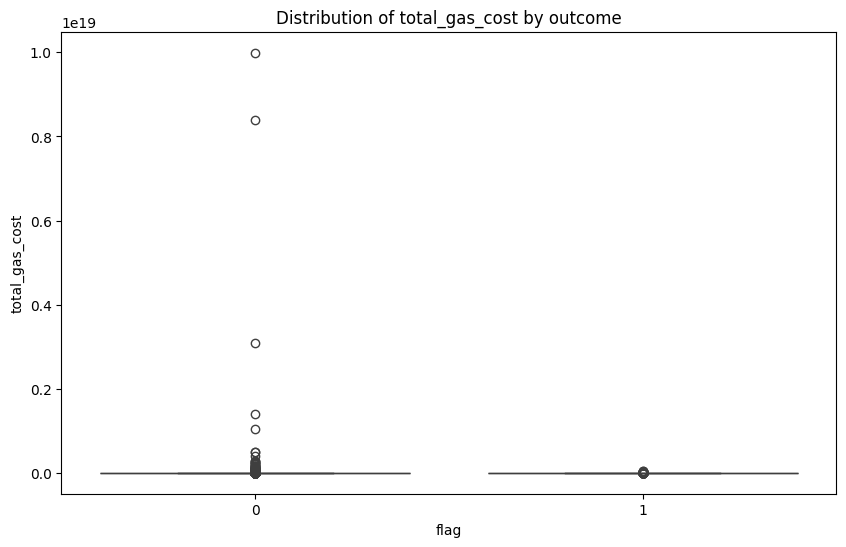

In [ ]:
data_preparation.plot_feature_by_fraud_flag(X_train, y_train, 'total_gas_cost')

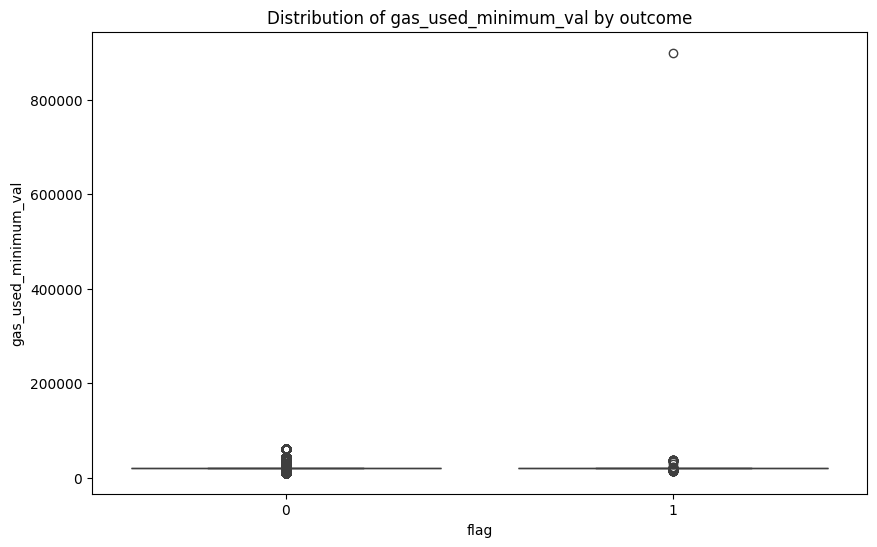

In [ ]:
data_preparation.plot_feature_by_fraud_flag(X_train, y_train, 'gas_used_minimum_val')

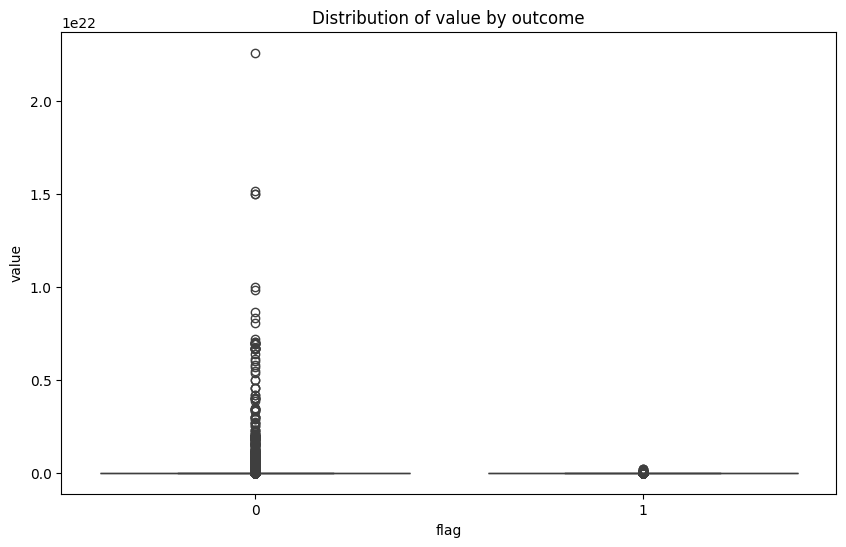

In [ ]:
data_preparation.plot_feature_by_fraud_flag(X_train, y_train,'value')

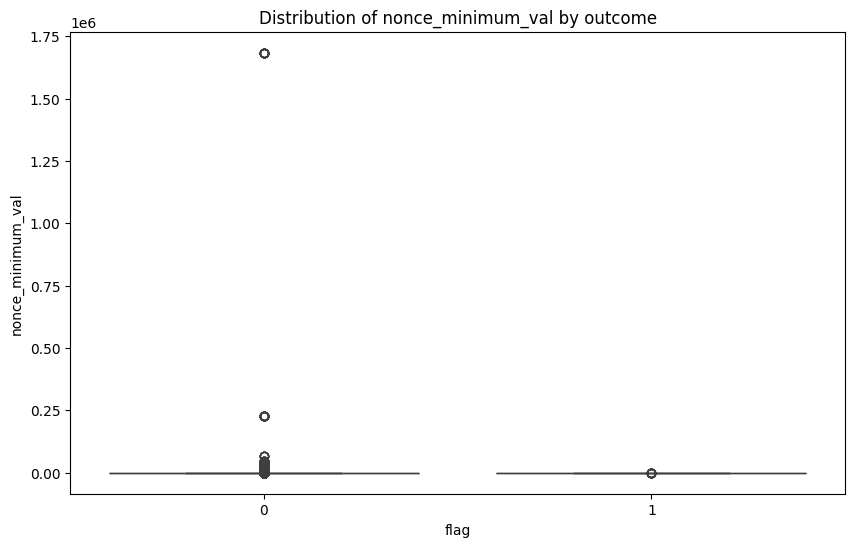

In [ ]:
data_preparation.plot_feature_by_fraud_flag(X_train, y_train,'nonce_minimum_val')

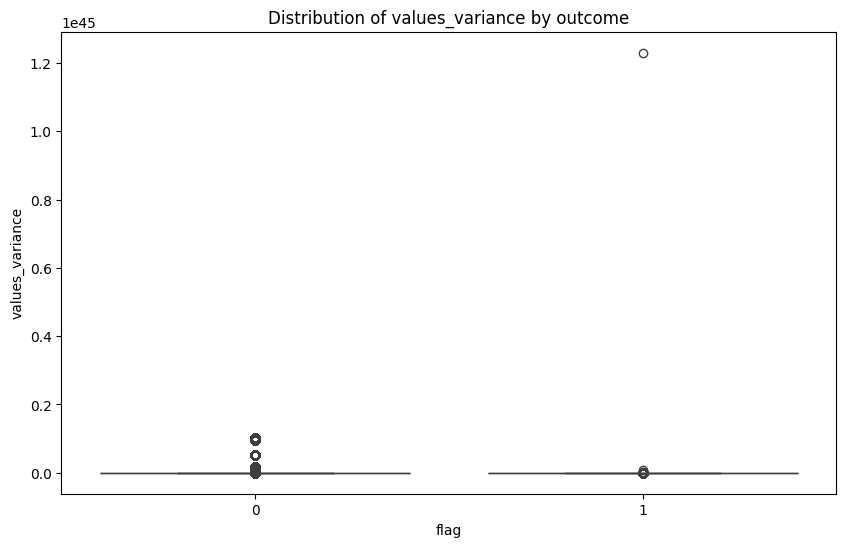

In [ ]:
data_preparation.plot_feature_by_fraud_flag(X_train, y_train,'values_variance')

In [ ]:
num_X = X_train.select_dtypes(include=[np.number])

inf_cols = num_X.columns[np.isinf(num_X).any()]
inf_cols.tolist()

['token_transfer_amount']

In [ ]:
X_train['token_transfer_amount'].describe()

,token_transfer_amount
count,40000.0
mean,inf
std,NaN
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,inf


In [ ]:
X_train['length_to_address'].describe()

,length_to_address
count,16000.000000
mean,41.485500
std,4.620132
min,0.000000
25%,42.000000
50%,42.000000
75%,42.000000
max,42.000000


In [ ]:
features_to_drop = ['message', 'status', 'coming_from_contract', 'Error!', 'gas_price_ratio', 'gas_per_log_event','log_count', 'log_removed', 'log_index', 'length_log', 'normalized_token_transfer','length_from_address','length_transaction_hash']

data_preparation.update_features(features_to_drop)

X_train_u, X_test_u, y_train_u, y_test_u, groups_train_u, groups_test_u = data_ingestion.get_processed_data(dataset_path)

print(f"X_train shape: {X_train_u.shape}")
print(f"X_test shape: {X_test_u.shape}")
X_train_u.head(5)

Unique wallet-feature fingerprints: 2111
Unique addresses:                   2115
X_train shape: (41746, 75)
X_test shape: (8254, 75)


,gas_used_coefficient_of_variation,event_activity_flag,gas_prices_summation,number_of_unique_to_address,values_coefficient_of_variation,values_mode,duration,gas_used_mode,gas_prices_minimum_val,values_average,gas_used_maximum_val,nonce_median,values_standard_deviation,value,number_of_unique_from_address,values_range_value,effective_gas_price,gas_prices_maximum_val,cumulativeGasUsed_range_value,values_maximum_val,nonce_coefficient_of_variation,gas_prices_standard_deviation,number_of_to_address,gas_prices_variance,cumulativeGasUsed_minimum_val,from_is_same_as_to_address,gas_efficiency,values_variance,values_summation,cumulativeGasUsed_coefficient_of_variation,cumulativeGasUsed_skewness,error_rate,cumulativeGasUsed_average,cumulativeGasUsed_standard_deviation,cumulative_gas_used,cumulativeGasUsed_median,cumulativeGasUsed_summation,gas_prices_range_value,gas_prices_skewness,cumulativeGasUsed_maximum_val,gas_used_average,values_minimum_val,gas_prices_average,nonce_maximum_val,token_transfer_amount,nonce_variance,values_median,gas_used_standard_deviation,gas_used_minimum_val,nonce_minimum_val,gas_prices_mode,chain_id,total_gas_cost,gas_prices_coefficient_of_variation,gas_used,values_skewness,cumulativeGasUsed_mode,index,gas_used_skewness,nonce_skewness,num_transaction,gas_used_variance,number_of_errors,number_of_from_address,length_to_address,nonce_summation,gas_used_summation,gas_used_median,gas_used_range_value,nonce_average,nonce_mode,cumulativeGasUsed_variance,nonce_standard_deviation,gas_prices_median,nonce_range_value
0,0.000000,0,1.250000e+18,4.0,1.468408,1.900000e+17,834.0,21000.0,0.000000e+00,1.010000e+17,21000.0,207896.5,1.480000e+17,9.560660e+16,2.0,8.050000e+18,2.100000e+10,2.100000e+15,6044687.0,8.050000e+18,1.137555,7.484880e+13,2904.0,5.600000e+27,21000.0,0,12.212000,2.200000e+34,2.930000e+20,1.462800,2.891299,0.000000,5.222840e+05,7.639970e+05,256452,235753.5,1.516713e+09,2.100000e+15,12.839167,6065687.0,21000.0000,7.329400e+14,4.307760e+14,4321181.0,0.0,3.957010e+11,9.570000e+16,0.000000,21000.0,0.0,4.200000e+14,1,4.410000e+14,0.173754,21000,53.072006,42000.0,4,0.000000,0.730690,2904.0,0.000000e+00,0.0,2904.0,42,1.605860e+09,6.098400e+07,21000.0,0.0,552982.129100,131653.0,5.836910e+11,6.290474e+05,4.200000e+14,4321181.0
1,0.174074,1,4.490000e+17,2.0,0.848942,1.100000e+18,14446.0,21000.0,0.000000e+00,5.090000e+17,30416.0,199883.0,4.320000e+17,6.024610e+17,10.0,3.990000e+18,2.152539e+10,3.287060e+15,6779581.0,4.000000e+18,2.804188,3.578510e+14,820.0,1.280000e+29,21000.0,0,60.531628,1.870000e+35,4.180000e+20,0.930182,1.494886,0.000000,1.351146e+06,1.256812e+06,1841130,932265.0,1.107940e+09,3.287060e+15,3.444865,6800581.0,23319.3561,5.396750e+15,5.470140e+14,7273548.0,0.0,1.030980e+12,2.500000e+17,4059.299183,21000.0,0.0,4.200000e+14,1,6.547160e+14,0.654190,30416,2.030777,21000.0,25,1.177400,4.810783,820.0,1.647791e+07,0.0,820.0,42,2.969146e+08,1.912187e+07,21000.0,9416.0,362090.939000,1.0,1.579580e+12,1.015371e+06,4.200000e+14,7273548.0
2,0.003676,0,1.980000e+18,6.0,6.122083,2.200000e+17,37757.0,21000.0,2.100000e+04,2.430000e+18,25907.0,418474.5,1.490000e+19,3.842040e+17,37.0,4.600000e+20,7.800000e+10,3.549000e+15,8493941.0,4.600000e+20,1.659145,3.995550e+14,4040.0,1.600000e+29,21000.0,0,34.673000,2.210000e+38,9.810000e+21,0.800933,0.665951,0.000000,2.634457e+06,2.110023e+06,728133,2154057.5,1.064320e+10,3.549000e+15,2.107617,8514941.0,21001.2146,0.000000e+00,4.909700e+14,12650551.0,0.0,1.689010e+12,1.010000e+18,77.201435,21000.0,0.0,4.200000e+14,1,1.638000e+15,0.813807,21000,21.486911,63000.0,31,63.537393,3.670446,4040.0,5.960062e+03,0.0,4040.0,42,3.164562e+09,8.484491e+07,21000.0,4907.0,783307.380000,380129.0,4.452200e+12,1.299621e+06,4.200000e+14,12650551.0
3,0.772656,1,1.530000e+19,24.0,8.580079,0.000000e+00,68986.0,87815.0,2.392400e+13,3.480000e+16,650000.0,2307.5,2.980000e+17,0.000000e+00,8.0,1.280000e+19,6.000000e+09,1.760000e+16,15216042.0,1.280000e+19,5.277200,3.512710e+15,4624.0,1.230000e+31,46092.0,0,18.8428

In [ ]:
#data_preparation.generate_profiling_report(X_train, '/content/drive/MyDrive/thesis_data/data_profiling_report_processesed.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


 91%|█████████ | 69/76 [00:01<00:00, 55.64it/s]/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1344: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean

100%|██████████| 76/76 [00:01<00:00, 49.55it/s]
/usr/local/lib/python3.12/dist-packages/data_profiling/model/correlations.py:87: UserWarning: There was an attempt to calculate the auto correlation, but this failed.
To hide this warning, disable the calculation
(using `df.profile_report(correlations={"auto": {"calculate": False}})`
If this is problematic for your use case, please report this as an issue:
https://github.com/Data-Centric-AI-Community/data-profiling/issues
(include the error messa

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Report generated! Check your file browser in Colab to download it.


In [ ]:
pipe_test = data_preparation.generate_preprocessing_pipeline()
result = pipe_test.fit_transform(X_train_u)

In [ ]:
result['length_to_address'].describe()

,length_to_address
count,16000.000000
mean,0.012250
std,0.110003
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
result['length_to_address'].value_counts()

,count
length_to_address,
0,15804
1,196


In [ ]:
result

,total_gas_cost,value,values_minimum_val,nonce_minimum_val,values_variance,gas_used_minimum_val,gas_used_skewness,gas_prices_mode,block_number,duration,number_of_unique_from_address,values_mode,error_rate,nonce_median,gas_prices_maximum_val,gas_prices_coefficient_of_variation,num_transaction,number_of_to_address,cumulativeGasUsed_variance,nonce_mode,cumulativeGasUsed_maximum_val,cumulativeGasUsed_minimum_val,gas_used_variance,gas_efficiency,values_skewness,cumulative_gas_used,gas_prices_median,cumulativeGasUsed_median,values_average,gas_used_standard_deviation,gas_used_range_value,nonce_variance,values_standard_deviation,gas_prices_range_value,number_of_from_address,cumulativeGasUsed_skewness,values_coefficient_of_variation,cumulativeGasUsed_mode,values_median,nonce_coefficient_of_variation,gas_used_summation,gas_used_mode,gas_prices_standard_deviation,cumulativeGasUsed_standard_deviation,gas_used_coefficient_of_variation,gas_used,number_of_errors,cumulativeGasUsed_summation,values_range_value,nonce_average,nonce_skewness,effective_gas_price,values_maximum_val,number_of_unique_to_address,nonce_summation,gas_prices_minimum_val,gas_prices_skewness,gas_prices_summation,nonce_maximum_val,gas_used_maximum_val,cumulativeGasUsed_range_value,cumulativeGasUsed_coefficient_of_variation,nonce_standard_deviation,index,gas_prices_variance,gas_used_average,gas_prices_average,token_transfer_amount,values_summation,nonce_range_value,gas_used_median,cumulativeGasUsed_average,length_to_address,chain_id,from_is_same_as_to_address,event_activity_flag
4881,-0.241074,0.605135,1.004642,0.000000,1.430681,0.000000,1.734006,-0.351649,-0.996143,0.604294,-0.448995,-0.175693,-0.263047,-0.226588,-0.122947,-0.610078,0.950582,0.950582,-0.559192,-0.270960,-0.676397,-0.145995,-0.188990,-0.662346,1.218333,-0.738229,-0.383161,-0.842312,2.557036,-0.400060,-0.330113,-0.290575,5.744969,-0.123019,0.950582,0.477129,0.047394,-0.260306,0.997263,-0.432803,-0.190520,-0.321754,-0.140564,-1.112815,-0.551326,-0.275286,-0.211411,-0.615580,7.439244,-0.394474,-0.621482,-0.276472,7.439245,2.981975,-0.331842,1.057542,0.763124,-0.191850,-0.494008,-0.330417,-0.672944,0.817802,-0.433309,-0.760823,-0.114018,-0.387436,-0.297142,0.0,2.638749,-0.493808,-0.319491,-1.017241,0,0,0,0
9245,0.397064,0.388863,0.896543,0.000000,-0.133046,0.000000,-0.645738,-0.351649,-0.544980,-1.022182,-0.444753,-0.175538,-0.263047,-0.212392,-0.121909,-0.325802,-0.041705,-0.041705,-0.290867,-0.270960,0.385965,-0.145995,-0.188589,-0.584562,-0.257523,-0.635847,-0.260169,-0.663140,-0.263193,-0.363262,-0.375711,0.175048,-0.274829,-0.121852,-0.041705,0.086095,-0.533004,-0.260306,-0.152748,-0.263034,-0.279364,-0.321754,-0.134766,-0.223198,-0.365833,-0.187622,-0.211411,-0.332790,-0.249892,0.401416,-0.353382,-0.112063,-0.249893,-0.492936,0.799901,-0.791655,-0.474390,-0.202123,2.105151,-0.376015,0.388136,0.650183,0.945624,-0.619192,-0.114014,-0.343756,-0.249087,0.0,-0.253485,2.105252,-0.319491,-0.554896,0,1,0,1
3722,0.520817,0.228982,0.979139,0.000000,-0.132096,0.000000,-0.671232,-0.118822,0.857753,0.259733,-0.440511,-0.178763,-0.263047,-0.229815,-0.123009,-0.245648,-1.512722,-1.512722,0.590358,-0.270960,-0.188792,0.477221,-0.189029,0.063602,-0.915522,-0.155786,-0.095143,-0.277322,-0.263110,-0.415473,-0.380785,-0.201912,-0.274822,-0.122970,-1.512722,-0.368100,-0.533254,0.125139,-0.184683,-0.234575,-0.480254,-0.321754,-0.129274,1.054470,-0.647966,-0.275286,-0.211411,-0.880356,-0.250903,-0.086983,-0.450290,0.388507,-0.250903,-0.494319,-0.336687,-0.535785,-0.623703,-0.290455,0.043741,-0.381089,-0.197184,-0.027734,0.167664,0.230593,-0.114002,-0.388112,-0.178142,0.0,-0.259424,0.043920,-0.319491,0.456850,0,1,0,0
15825,0.721912,-5.864026,0.000000,0.000000,-1.640424,-0.165315,1.578365,-0.023997,-0.054643,-0.787812,1.374043,-0.181865,-0.081712,-0.229775,-0.078025,0.700244,0.950582,0.950582,-0.027191,-0.270949,-0.181099,-0.075094,0.008725,-0.463124,1.290854,-0.324694,0.019771,0.137994,-0.272932,0.692111,3.052428,-0.290576,-0.276

## Models comparison

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

def evaluate_model(X_test, y_test, model, model_name):
    #To ensure y_test is a flat 1D array to avoid dimension errors
    #.values handles the conversion, .ravel() ensures it is 1D
    y_true = y_test.values.ravel() if hasattr(y_test, 'values') else y_test

    #Get predictions
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    #Compute metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )

    #Compute PR-AUC and ROC-AUC
    pr_auc = average_precision_score(y_true, y_probs)
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    precision_array, recall_array, _ = precision_recall_curve(y_true, y_probs)

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc,
        "fpr": fpr,
        "tpr": tpr,
        "Precision_array": precision_array,
        "Recall_array": recall_array
    }

    return results

def plot_pr_curves(results_list):
    plt.figure(figsize=(8, 6), dpi=300)

    for res in results_list:
        plt.plot(res['Recall_array'], res['Precision_array'],
                 label=f"{res['Model']} (AUC={res['PR-AUC']:.3f})")


    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall curve comparison')

    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.7)
    #plt.savefig('pr_curve_comparison.pdf', bbox_inches='tight')
    pos_fraction = sum(y_test) / len(y_test)
    plt.axhline(y=pos_fraction, color='r', linestyle=':', label='No Skill')
    plt.show()

def plot_learning_curve_modifies(pipeline, X, y, groups, title, save_path=None):

    cv_strategy = StratifiedGroupKFold(n_splits=5, shuffle=True,
                                       random_state=42)
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X, y,
        groups=groups,
        cv=cv_strategy,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8),
        scoring='average_precision',
        shuffle=True, random_state=42,
        error_score='raise',
    )

    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    val_mean,   val_std   = val_scores.mean(axis=1),   val_scores.std(axis=1)

    plt.figure(figsize=(10, 6), dpi=300)
    plt.title(f"Learning Curve: {title}")
    plt.xlabel("Training set size")
    plt.ylabel("PR-AUC")
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    plt.fill_between(train_sizes, train_mean - train_std,
                     train_mean + train_std, alpha=0.1, color="r")
    plt.plot(train_sizes, val_mean, 'o-', color="g", label="Cross-validation score")
    plt.fill_between(train_sizes, val_mean - val_std,
                     val_mean + val_std, alpha=0.1, color="g")
    plt.legend(loc="best")
    plt.grid(True)
    # if save_path:
    #     plt.savefig(save_path, bbox_inches="tight")   # .pdf for the thesis
    plt.show()


def plot_learning_curve(pipeline, X, y, title):

    plt.figure(figsize=(10, 6), dpi=300)
    train_sizes_ = np.linspace(0.2, 1.0, 5)

    #Calculate learning curve
    #Use the full pipeline so that preprocessing happens inside the CV loop
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X, y, cv=5, n_jobs=-1,
        train_sizes=train_sizes_,
        scoring='f1',
        error_score='raise' # Helps identify if a split has 0 positive classes
    )

    #Calculate metrics
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    val_scores_mean = np.mean(val_scores, axis=1)
    val_scores_std = np.std(val_scores, axis=1)

    #Plot
    plt.figure(figsize=(10, 6))
    plt.title(f"Learning Curve: {title}")
    plt.xlabel("Training set size")
    plt.ylabel("F1 Score")

    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")

    plt.plot(train_sizes, val_scores_mean, 'o-', color="g", label="Cross validation score")
    plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                     val_scores_mean + val_scores_std, alpha=0.1, color="g")

    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

In [ ]:
preprocess_pipeline = data_preparation.generate_preprocessing_pipeline()
# random forest pipeline
rf_pipe = Pipeline(steps=[
    ('preprocess', preprocess_pipeline),
    ('rf', RandomForestClassifier(
         random_state=42,
         n_jobs=4
    ))
])

preprocess_pipeline.fit_transform(X_train_u)

,nonce_minimum_val,value,total_gas_cost,gas_used_minimum_val,values_variance,values_minimum_val,nonce_standard_deviation,nonce_maximum_val,token_transfer_amount,gas_used_coefficient_of_variation,gas_prices_summation,values_median,values_coefficient_of_variation,values_mode,duration,gas_used_standard_deviation,gas_used_mode,gas_prices_minimum_val,nonce_variance,number_of_unique_to_address,values_average,gas_used_maximum_val,nonce_median,values_standard_deviation,gas_prices_mode,values_range_value,number_of_unique_from_address,gas_prices_median,effective_gas_price,gas_prices_coefficient_of_variation,gas_used,gas_prices_maximum_val,values_skewness,cumulativeGasUsed_range_value,index,gas_used_skewness,cumulativeGasUsed_mode,values_maximum_val,gas_prices_standard_deviation,nonce_coefficient_of_variation,number_of_errors,num_transaction,gas_used_variance,nonce_range_value,nonce_skewness,number_of_from_address,number_of_to_address,gas_prices_variance,nonce_summation,cumulativeGasUsed_minimum_val,gas_efficiency,gas_used_summation,values_summation,gas_used_median,cumulativeGasUsed_coefficient_of_variation,gas_used_range_value,cumulativeGasUsed_skewness,nonce_average,error_rate,cumulativeGasUsed_average,cumulativeGasUsed_standard_deviation,nonce_mode,cumulativeGasUsed_median,cumulativeGasUsed_summation,gas_prices_range_value,cumulativeGasUsed_variance,gas_prices_skewness,cumulativeGasUsed_maximum_val,gas_used_average,cumulative_gas_used,gas_prices_average,length_to_address,chain_id,from_is_same_as_to_address,event_activity_flag
0,0.0,-0.034791,-0.176352,0.000000,0.000000,0.970963,-0.091553,-0.032925,-0.264381,-0.673616,0.475774,-0.964883,-0.545596,-0.532433,-1.885727,-0.443167,-0.352395,-0.808470,-0.237492,-0.509636,-1.427233,-0.393011,-0.052682,-1.604738,-0.367085,0.292526,-0.437484,-0.389350,-0.014228,-0.570844,-0.301232,-0.329978,0.827605,-0.424262,-0.706657,-0.678752,-0.242497,0.289134,-0.141238,-0.378338,-0.228158,-0.851138,-0.197679,-0.032709,-0.589184,-0.851138,-0.851138,0.108757,-0.058745,-0.144126,-0.534039,-0.424786,0.265330,-0.344157,0.831401,-0.392712,0.215673,-0.019953,-0.280529,-0.838225,-0.760994,0.128909,-0.767614,-0.748743,-0.328561,-0.464215,0.143100,-0.427486,-0.419279,-0.638301,-0.314175,0,1,0,0
1,0.0,0.009622,0.213847,0.000000,0.000000,1.027598,0.097066,0.264540,-0.264381,-0.408118,-1.302136,-0.625347,-0.572159,1.152383,-1.310330,-0.397622,-0.352395,-0.808470,-0.203710,-0.510967,-0.450838,-0.388458,-0.058763,-0.850283,-0.367085,0.292526,-0.433522,-0.389350,-0.013718,-0.247671,-0.218870,-0.321744,-0.912316,-0.317318,-0.276041,-0.623961,-0.262342,0.289134,-0.135583,-0.202220,-0.228158,-1.364367,-0.197336,0.264750,-0.374936,-1.364367,-1.364367,0.108757,-0.276370,-0.144126,0.009142,-0.479487,0.265330,-0.344157,-0.369101,-0.388158,-0.196726,-0.140120,-0.280529,-0.302259,-0.304279,-0.255405,-0.307416,-0.786156,-0.320330,-0.314762,-0.424901,-0.320418,-0.391182,0.020830,-0.287870,0,1,0,1
2,0.0,-0.001232,1.119370,0.000000,0.000000,0.000000,0.235848,0.806297,-0.264381,-0.668010,0.475774,1.025021,-0.346048,-0.470032,-0.324943,-0.442301,-0.352395,-0.808470,-0.168718,-0.508306,0.724188,-0.390638,0.107117,0.658629,-0.367085,0.292526,-0.420151,-0.389350,0.041089,-0.140303,-0.301232,-0.319927,-0.249085,-0.067839,-0.153008,2.277993,-0.222652,0.289134,-0.134750,-0.323220,-0.228158,-0.571374,-0.197678,0.806496,-0.434816,-0.571374,-0.571374,0.108757,0.200405,-0.144126,-0.281546,-0.393608,0.265330,-0.344157,-0.660424,-0.390339,-0.441533,0.125037,-0.280529,0.527566,0.486431,0.854249,0.499846,0.086570,-0.318514,0.116332,-0.505755,-0.070650,-0.419265,-0.442110,-0.300553,0,1,0,0
3,0.0,-0.978152,0.000081,0.000000,0.000000,0.000000,-0.390866,-0.425674,-0.264381,0.504841,0.475774,-1.175470,-0.240650,-0.927636,0.995149,1.871121,0.380274,-0.704744,-0.258520,-0.496332,-1.585658,-0.088802,-0.208695,-1.206258,-0.183159,0.292526,-0.434513,0.504825,-0.028785,0.028446,0.283762,-0.222469,-0.016708,0.910380,-0.214524,-0.658321,0.221986,0.289134,-0.07254

In [ ]:
set_config(display="diagram")
rf_pipe

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('skew',
                                                  Pipeline(steps=[('clean_inf',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<function DataPreparation.generate_preprocessing_pipeline.<locals>.<lambda> at 0x787d56f14900>)),
                                                                  ('enforce_finite',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<function DataPreparation.ge...
                                                                                       func=<function DataPreparation.generate_preprocessing_pipeline.<locals>.<lambda> at 0x787d56f14ea0>))]),
                                                  ['length_to_address']),
                                                 ('flags',
                                                  Pipeline(steps=[('passthrough',
                                                                   FunctionTransformer(func=<function DataPreparation.generate_preprocessing_pipeline.<locals>.<lambda> at 0x787d56f14d60>))]),
                                                  ['chain_id',
                                                   'from_is_same_as_to_address',
                                                   'event_activity_flag'])],
                                   verbose_feature_names_out=False)),
                ('rf', RandomForestClassifier(n_jobs=4, random_state=42))])

In [ ]:

param_distributions = {
    'rf__n_estimators':      randint(100, 500),        # more trees
    'rf__max_depth':         [None, 10, 20, 30, 50],   # Non
    'rf__min_samples_split': randint(2, 20),
    'rf__min_samples_leaf':  randint(1, 10),
    'rf__max_features':      ['sqrt', 0.3, 0.5],
}

#ensure balanced folds
#cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_strategy = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions,
    n_iter=20,
    scoring='average_precision', #Using PR-AUC instead of default accuracy
    n_jobs=-1,
    cv=cv_strategy,         #the stratified strategy
    error_score='raise',
    verbose=1               #for debuging
)

search.fit(X_train_u, y_train_u, groups = groups_train_u)
print("Best CV score = %0.3f:" % search.best_score_)
print("Best parameters: ", search.best_params_)

#store the best params and best model for later use
RF_best_params = search.best_params_
RF_best_model = search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV score = 0.939:
Best parameters:  {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 7, 'rf__min_samples_split': 13, 'rf__n_estimators': 147}


In [ ]:
std  = search.cv_results_['std_test_score'][search.best_index_]
print(f" CV PR-AUC = {search.best_score_:.4f} ± {std:.4f}")

 CV PR-AUC = 0.9391 ± 0.0288


In [ ]:
results = evaluate_model(X_test_u, y_test_u, RF_best_model, 'Random Forest')

print(f"f1 score = {results['F1-Score']}" )
print(f"PR Auc = {results['PR-AUC']}")
print(f"Roc Auc = {results['ROC-AUC']} ")
print(f"Precision = {results['Precision']}")
print(f"Recall = {results['Recall']}")

f1 score = 0.7617801047120419
PR Auc = 0.8907952895271566
Roc Auc = 0.985590432134861 
Precision = 0.941747572815534
Recall = 0.6395604395604395


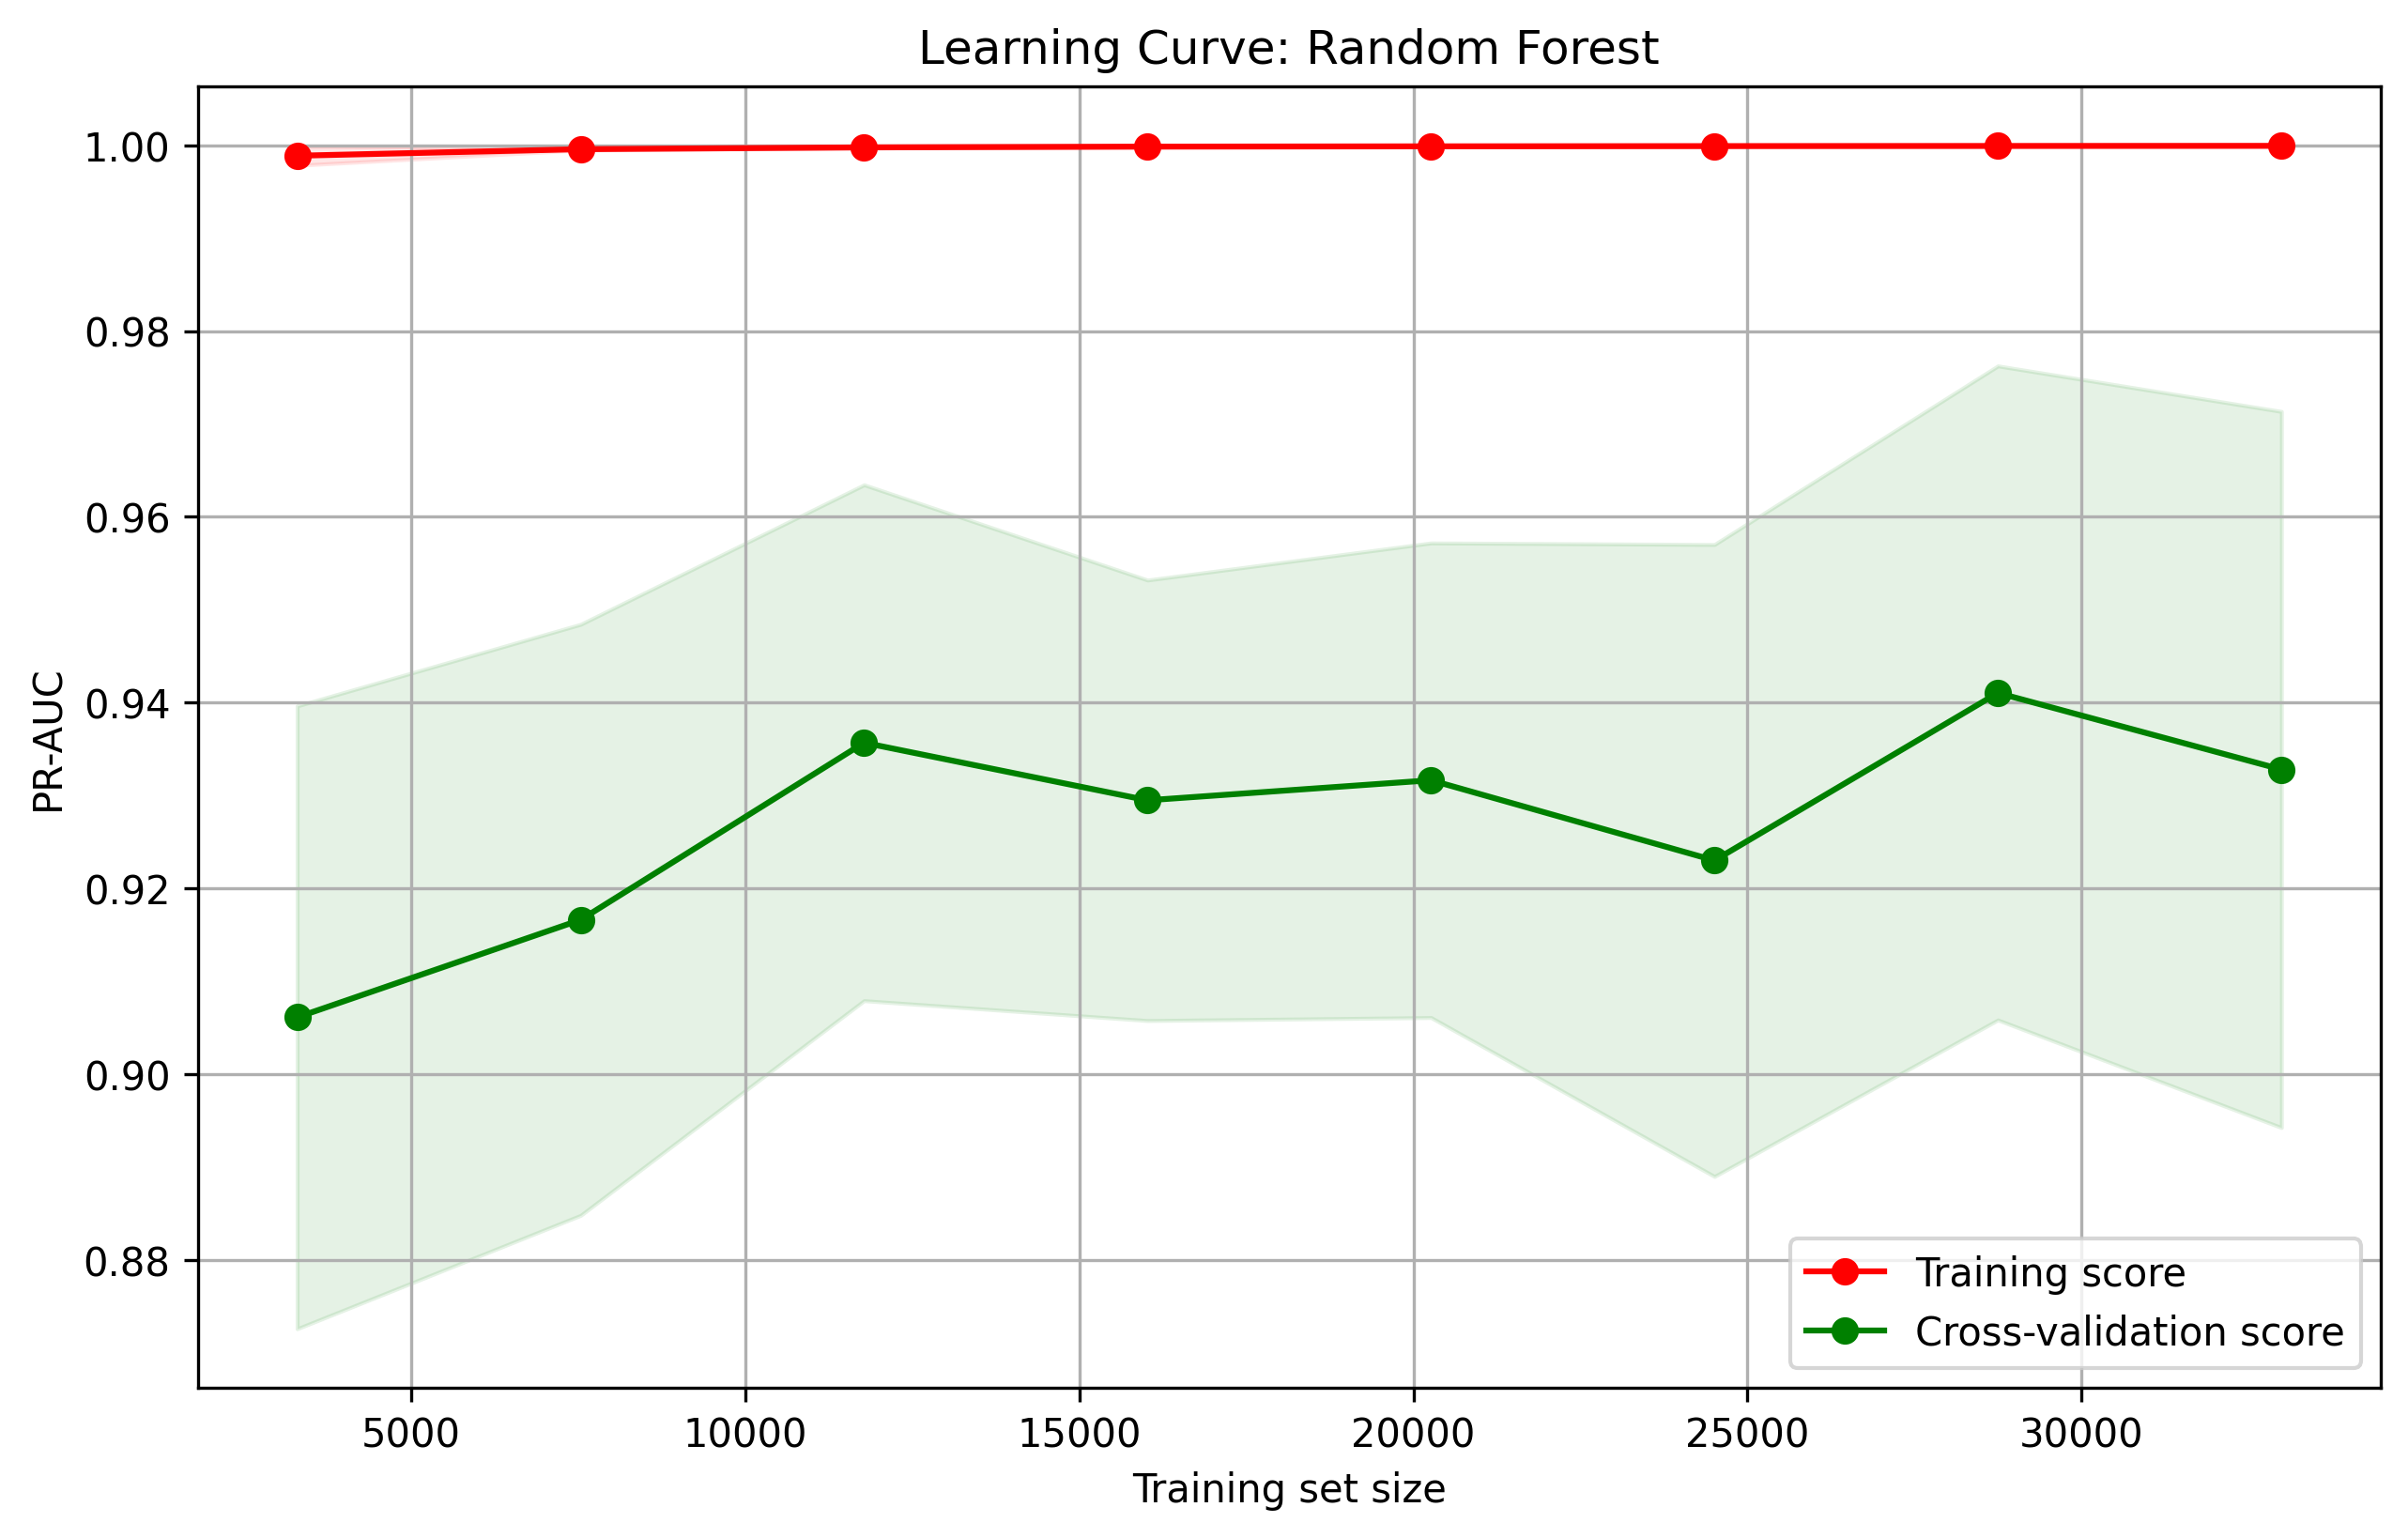

In [ ]:
plot_learning_curve_modifies(RF_best_model, X_train_u, y_train_u, groups_train_u, title= "Random Forest", save_path="figures/lc_rf.pdf")

In [ ]:
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

#XGBoost pipeline
xgb_pipe = Pipeline(steps=[
    ('preprocess', preprocess_pipeline),
     ('xgb', XGBClassifier(
         eval_metric='logloss',
         random_state=42,
         n_jobs=4,
         tree_method='hist'
    ))
])

#ensure balanced folds
#cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_strategy = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)


#XGBoost grid
xgb_param_dist = {
    'xgb__n_estimators':      randint(100, 600),
    'xgb__max_depth':         randint(3, 11),
    'xgb__learning_rate':     loguniform(0.01, 0.3),
    'xgb__subsample':         uniform(0.6, 0.4),
    'xgb__colsample_bytree':  uniform(0.6, 0.4),
    'xgb__min_child_weight':  randint(1, 10)
}

search_xgb = RandomizedSearchCV(
    xgb_pipe,
    xgb_param_dist,
    n_iter=20,
    scoring='average_precision', #Using PR-AUC instead of default accuracy
    n_jobs=-1,
    cv=cv_strategy,         #the stratified strategy
    error_score='raise',
    verbose=1               #for debuging
)

search_xgb.fit(X_train_u, y_train_u, groups = groups_train_u)
print("Best CV score = %0.3f:" % search_xgb.best_score_)
print("Best parameters: ", search_xgb.best_params_)

#store the best params and best model for later use
XGB_best_params = search_xgb.best_params_
XGB_best_model = search_xgb.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV score = 0.959:
Best parameters:  {'xgb__colsample_bytree': np.float64(0.6565120020788161), 'xgb__learning_rate': np.float64(0.20310041357029396), 'xgb__max_depth': 4, 'xgb__min_child_weight': 2, 'xgb__n_estimators': 299, 'xgb__subsample': np.float64(0.9042395415456184)}


In [ ]:
std  = search_xgb.cv_results_['std_test_score'][search_xgb.best_index_]
print(f" CV PR-AUC = {search_xgb.best_score_:.4f} ± {std:.4f}")

 CV PR-AUC = 0.9592 ± 0.0228


In [ ]:
results_xgb = evaluate_model(X_test_u, y_test_u, XGB_best_model, 'XGBoost')

print(f"f1 score = {results_xgb['F1-Score']}" )
print(f"PR Auc = {results_xgb['PR-AUC']}")
print(f"Roc Auc = {results_xgb['ROC-AUC']} ")
print(f"Precision = {results_xgb['Precision']}")
print(f"Recall = {results_xgb['Recall']}")

f1 score = 0.7170542635658915
PR Auc = 0.8827174731772738
Roc Auc = 0.9864986917173095 
Precision = 0.6412478336221837
Recall = 0.8131868131868132


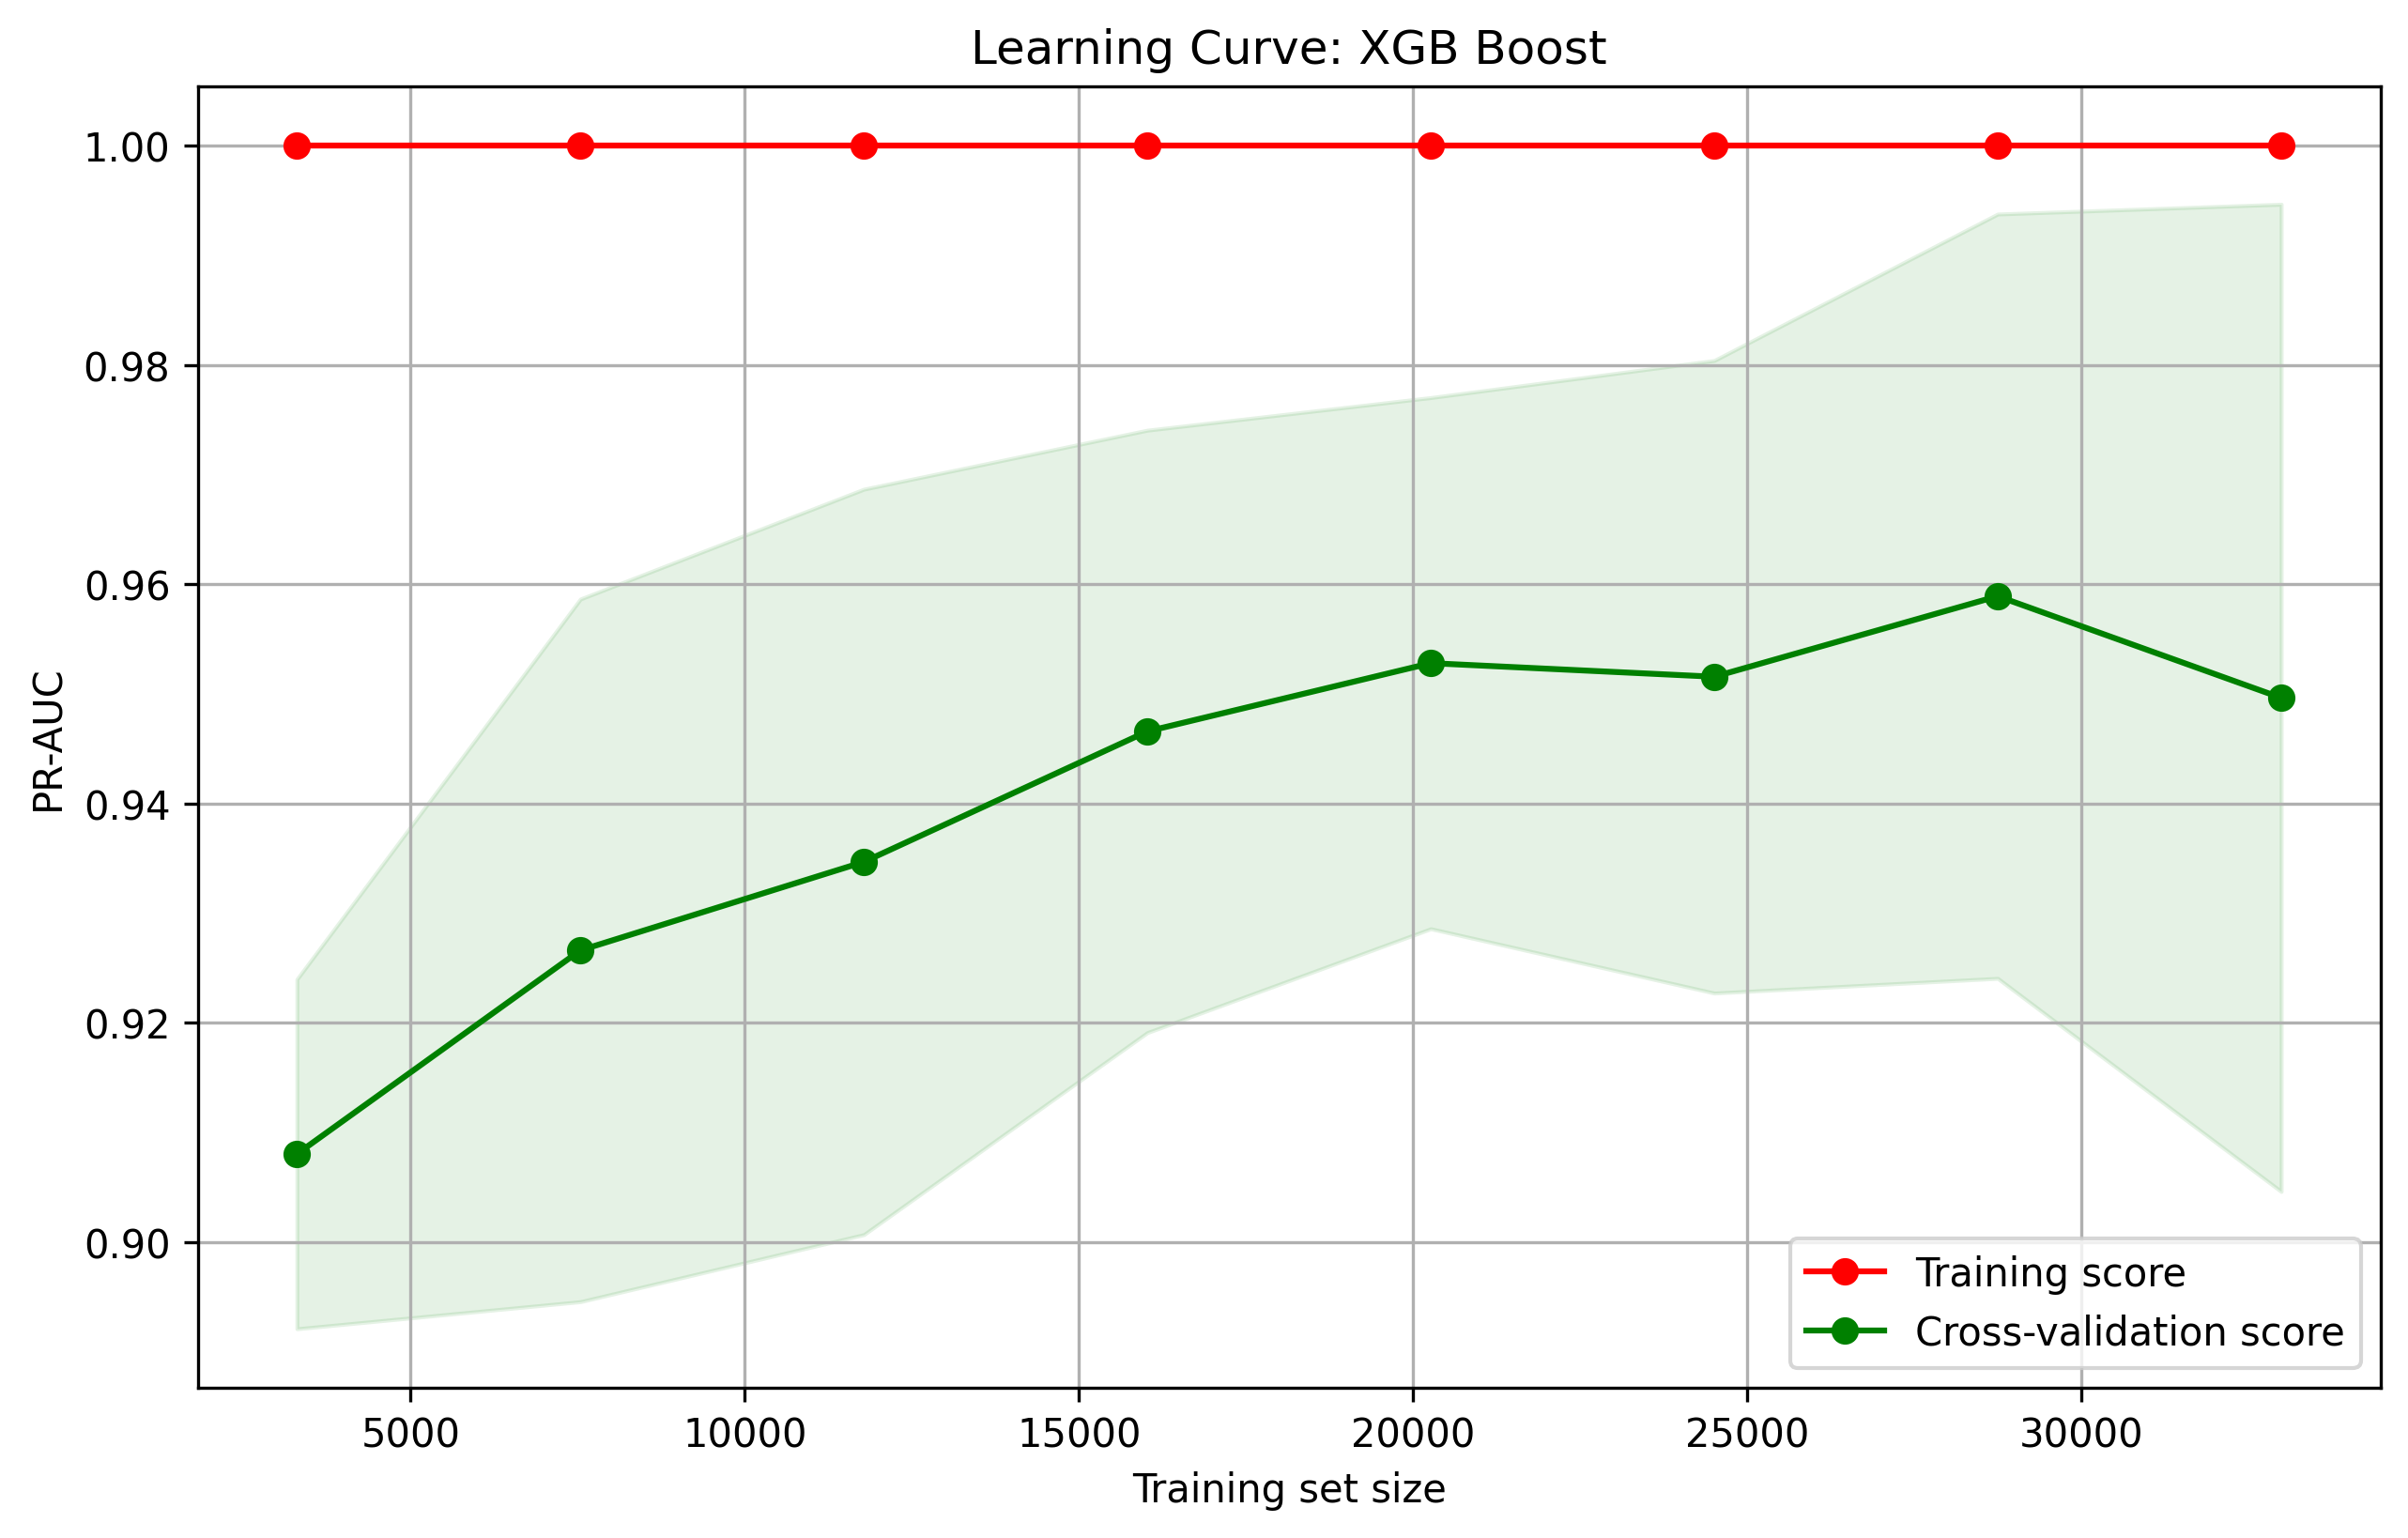

In [ ]:
plot_learning_curve_modifies(XGB_best_model, X_train_u, y_train_u, groups_train_u, "XGB Boost")

In [ ]:
from lightgbm import LGBMClassifier

#LightGBM pipeline
lgbm_pipe = Pipeline(steps=[
    ('preprocess', preprocess_pipeline),
    ('lgbm', LGBMClassifier(
        verbose=-1,
        random_state=42,
        n_jobs=4,
    ))
])

lgbm_param_dist = {
    'lgbm__n_estimators':      randint(100, 600),
    'lgbm__num_leaves':        randint(20, 150),
    'lgbm__max_depth':         [-1, 6, 9, 12],
    'lgbm__learning_rate':     loguniform(0.01, 0.3),
    'lgbm__subsample':         uniform(0.6, 0.4),
    'lgbm__subsample_freq':    [1],
    'lgbm__colsample_bytree':  uniform(0.6, 0.4),
    'lgbm__min_child_samples': randint(5, 50),
}

cv_strategy = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

search_lgbm = RandomizedSearchCV(
    lgbm_pipe,
    lgbm_param_dist,
    n_iter=20,
    scoring='average_precision',
    n_jobs=-1,
    cv=cv_strategy,
    error_score='raise')

search_lgbm.fit(X_train_u, y_train_u, groups = groups_train_u)

print("Best CV score = %0.3f:" % search_lgbm.best_score_)
print("Best parameters: ", search_lgbm.best_params_)

#store the best params and best model for later use
LGBM_best_params = search_lgbm.best_params_
LGBM_best_model = search_lgbm.best_estimator_

Best CV score = 0.969:
Best parameters:  {'lgbm__colsample_bytree': np.float64(0.7045205478300625), 'lgbm__learning_rate': np.float64(0.2350889399957945), 'lgbm__max_depth': -1, 'lgbm__min_child_samples': 48, 'lgbm__n_estimators': 342, 'lgbm__num_leaves': 53, 'lgbm__subsample': np.float64(0.6012659622264274), 'lgbm__subsample_freq': 1}


In [ ]:
std  = search_lgbm.cv_results_['std_test_score'][search_lgbm.best_index_]
print(f" CV PR-AUC = {search_lgbm.best_score_:.4f} ± {std:.4f}")

 CV PR-AUC = 0.9691 ± 0.0144


In [ ]:
results_lgbm = evaluate_model(X_test_u, y_test_u, LGBM_best_model, 'LGBM Boost')

print(f"f1 score = {results_lgbm['F1-Score']}" )
print(f"PR Auc = {results_lgbm['PR-AUC']}")
print(f"Roc Auc = {results_lgbm['ROC-AUC']} ")
print(f"Precision = {results_lgbm['Precision']}")
print(f"Recall = {results_lgbm['Recall']}")

f1 score = 0.7935723114956736
PR Auc = 0.8768017564905218
Roc Auc = 0.9810668879780304 
Precision = 0.9067796610169492
Recall = 0.7054945054945055


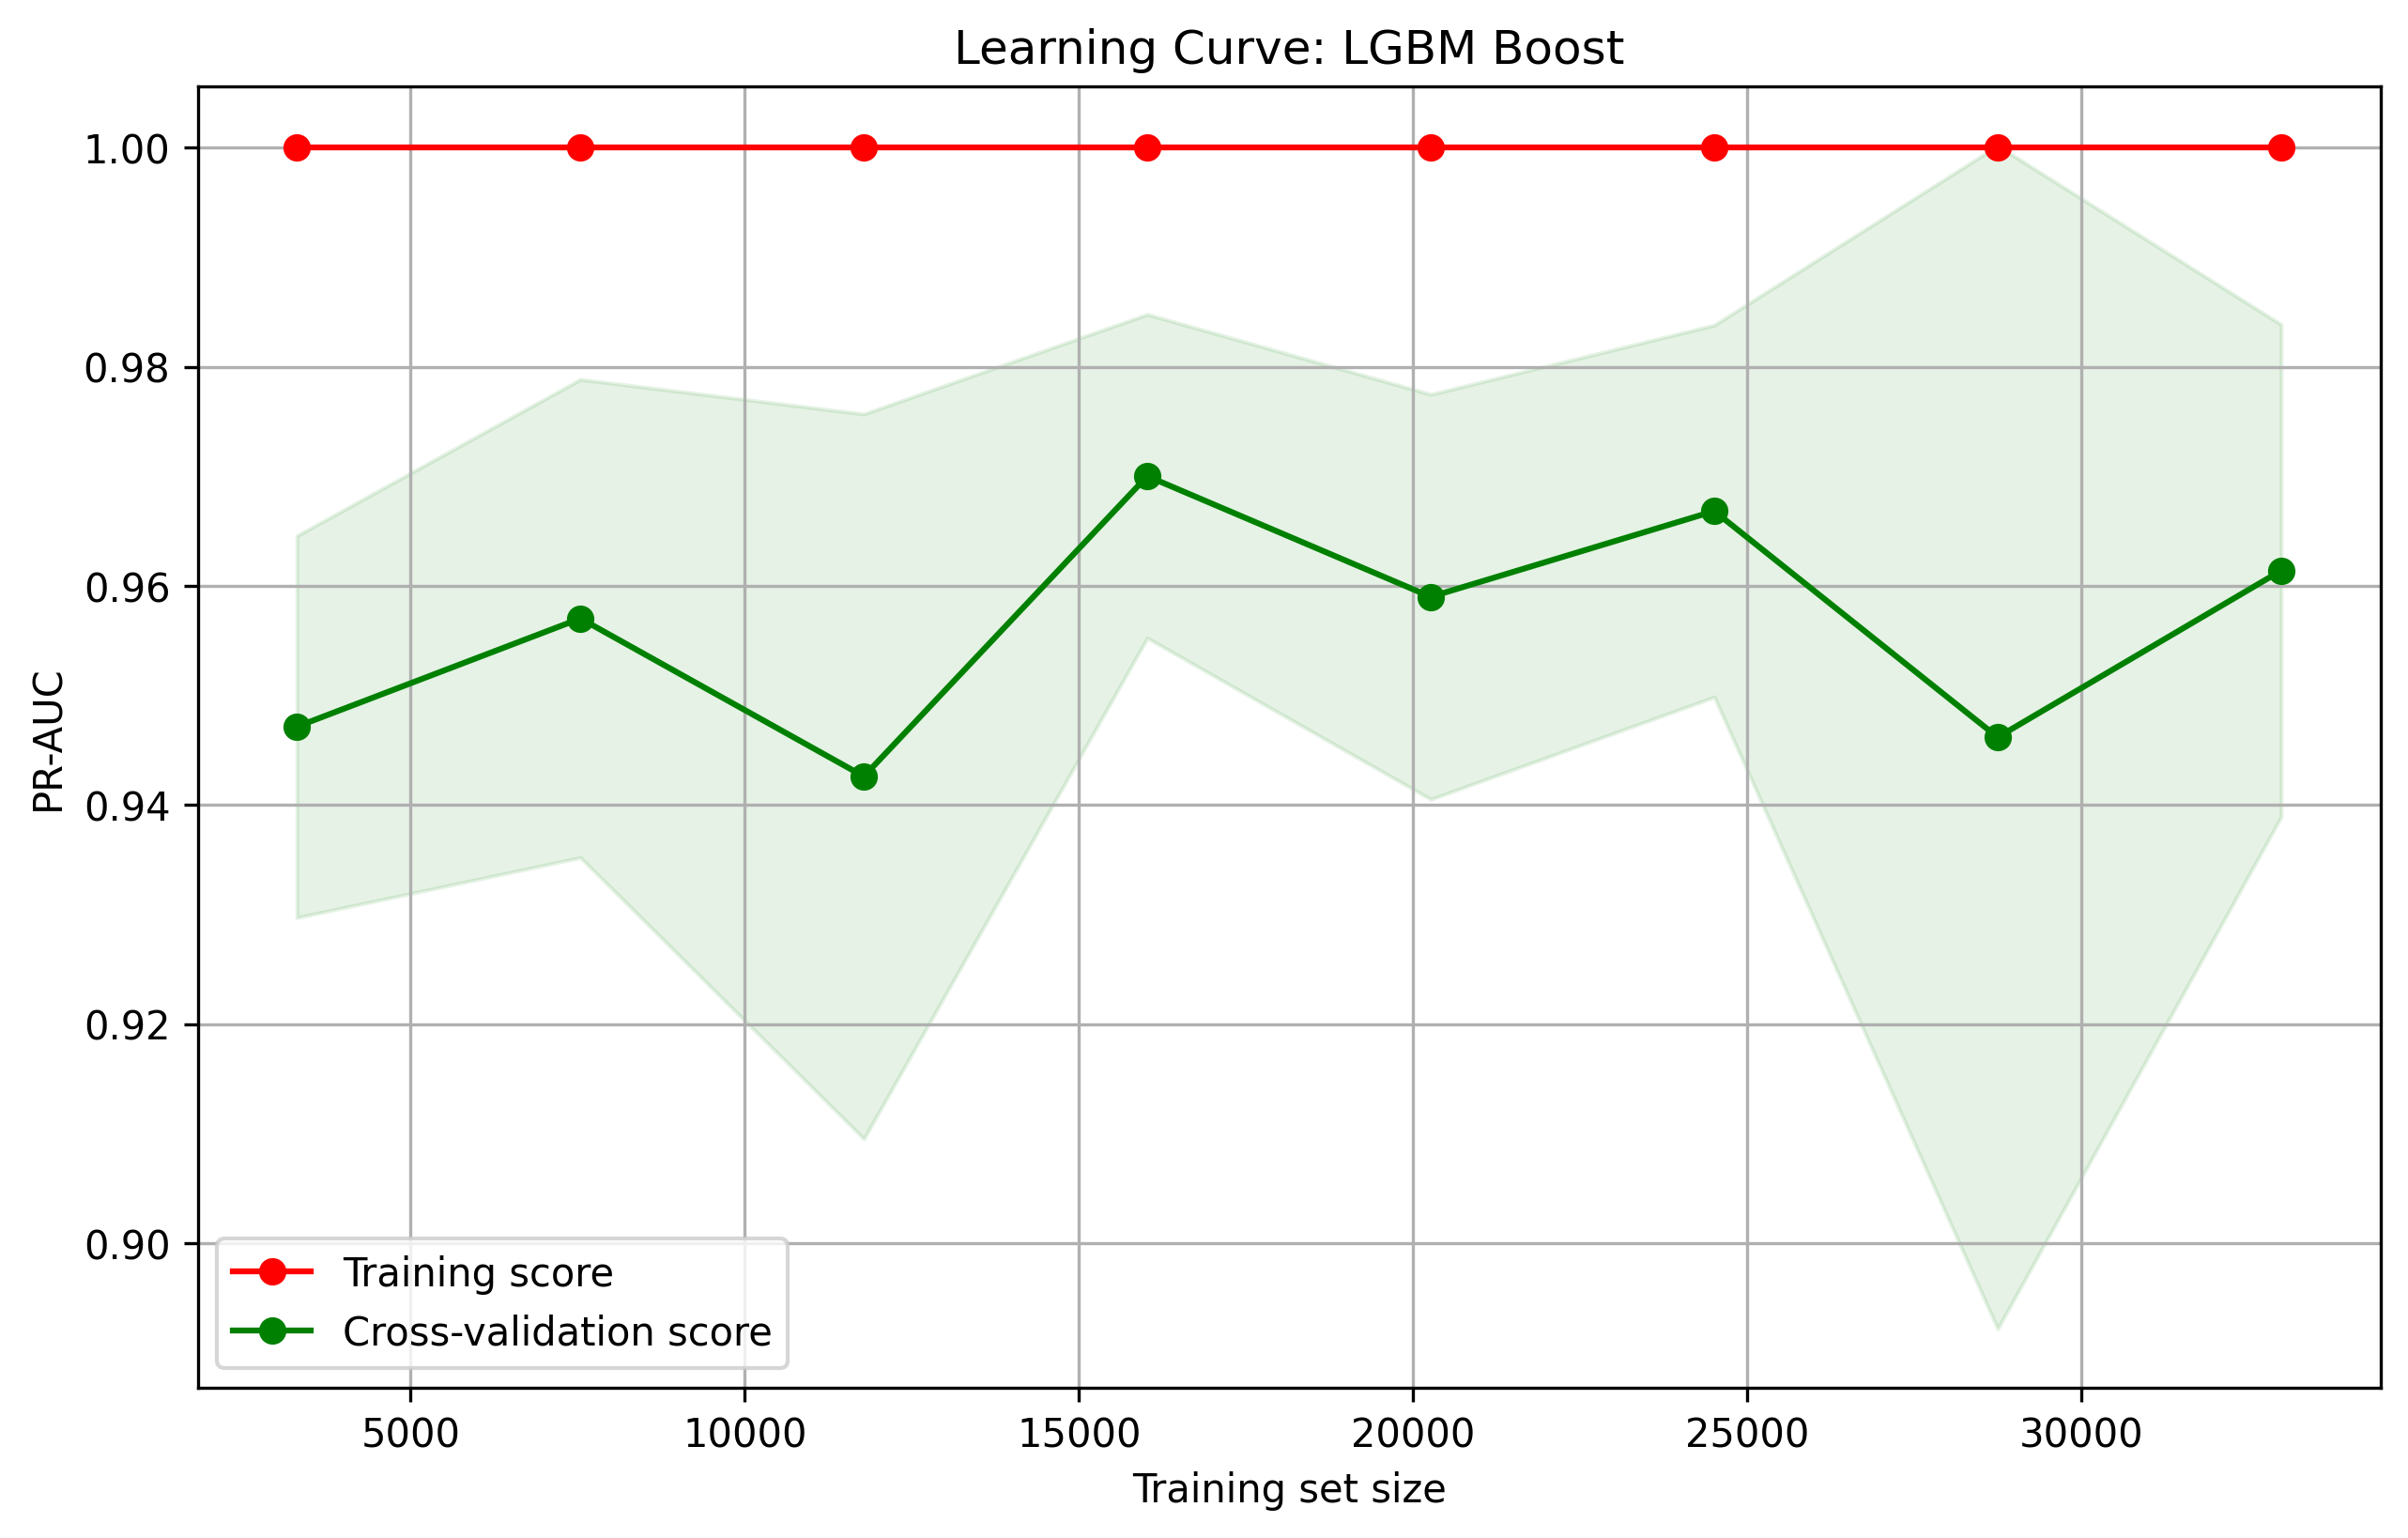

In [ ]:
plot_learning_curve_modifies(LGBM_best_model, X_train_u, y_train_u, groups_train_u, "LGBM Boost")

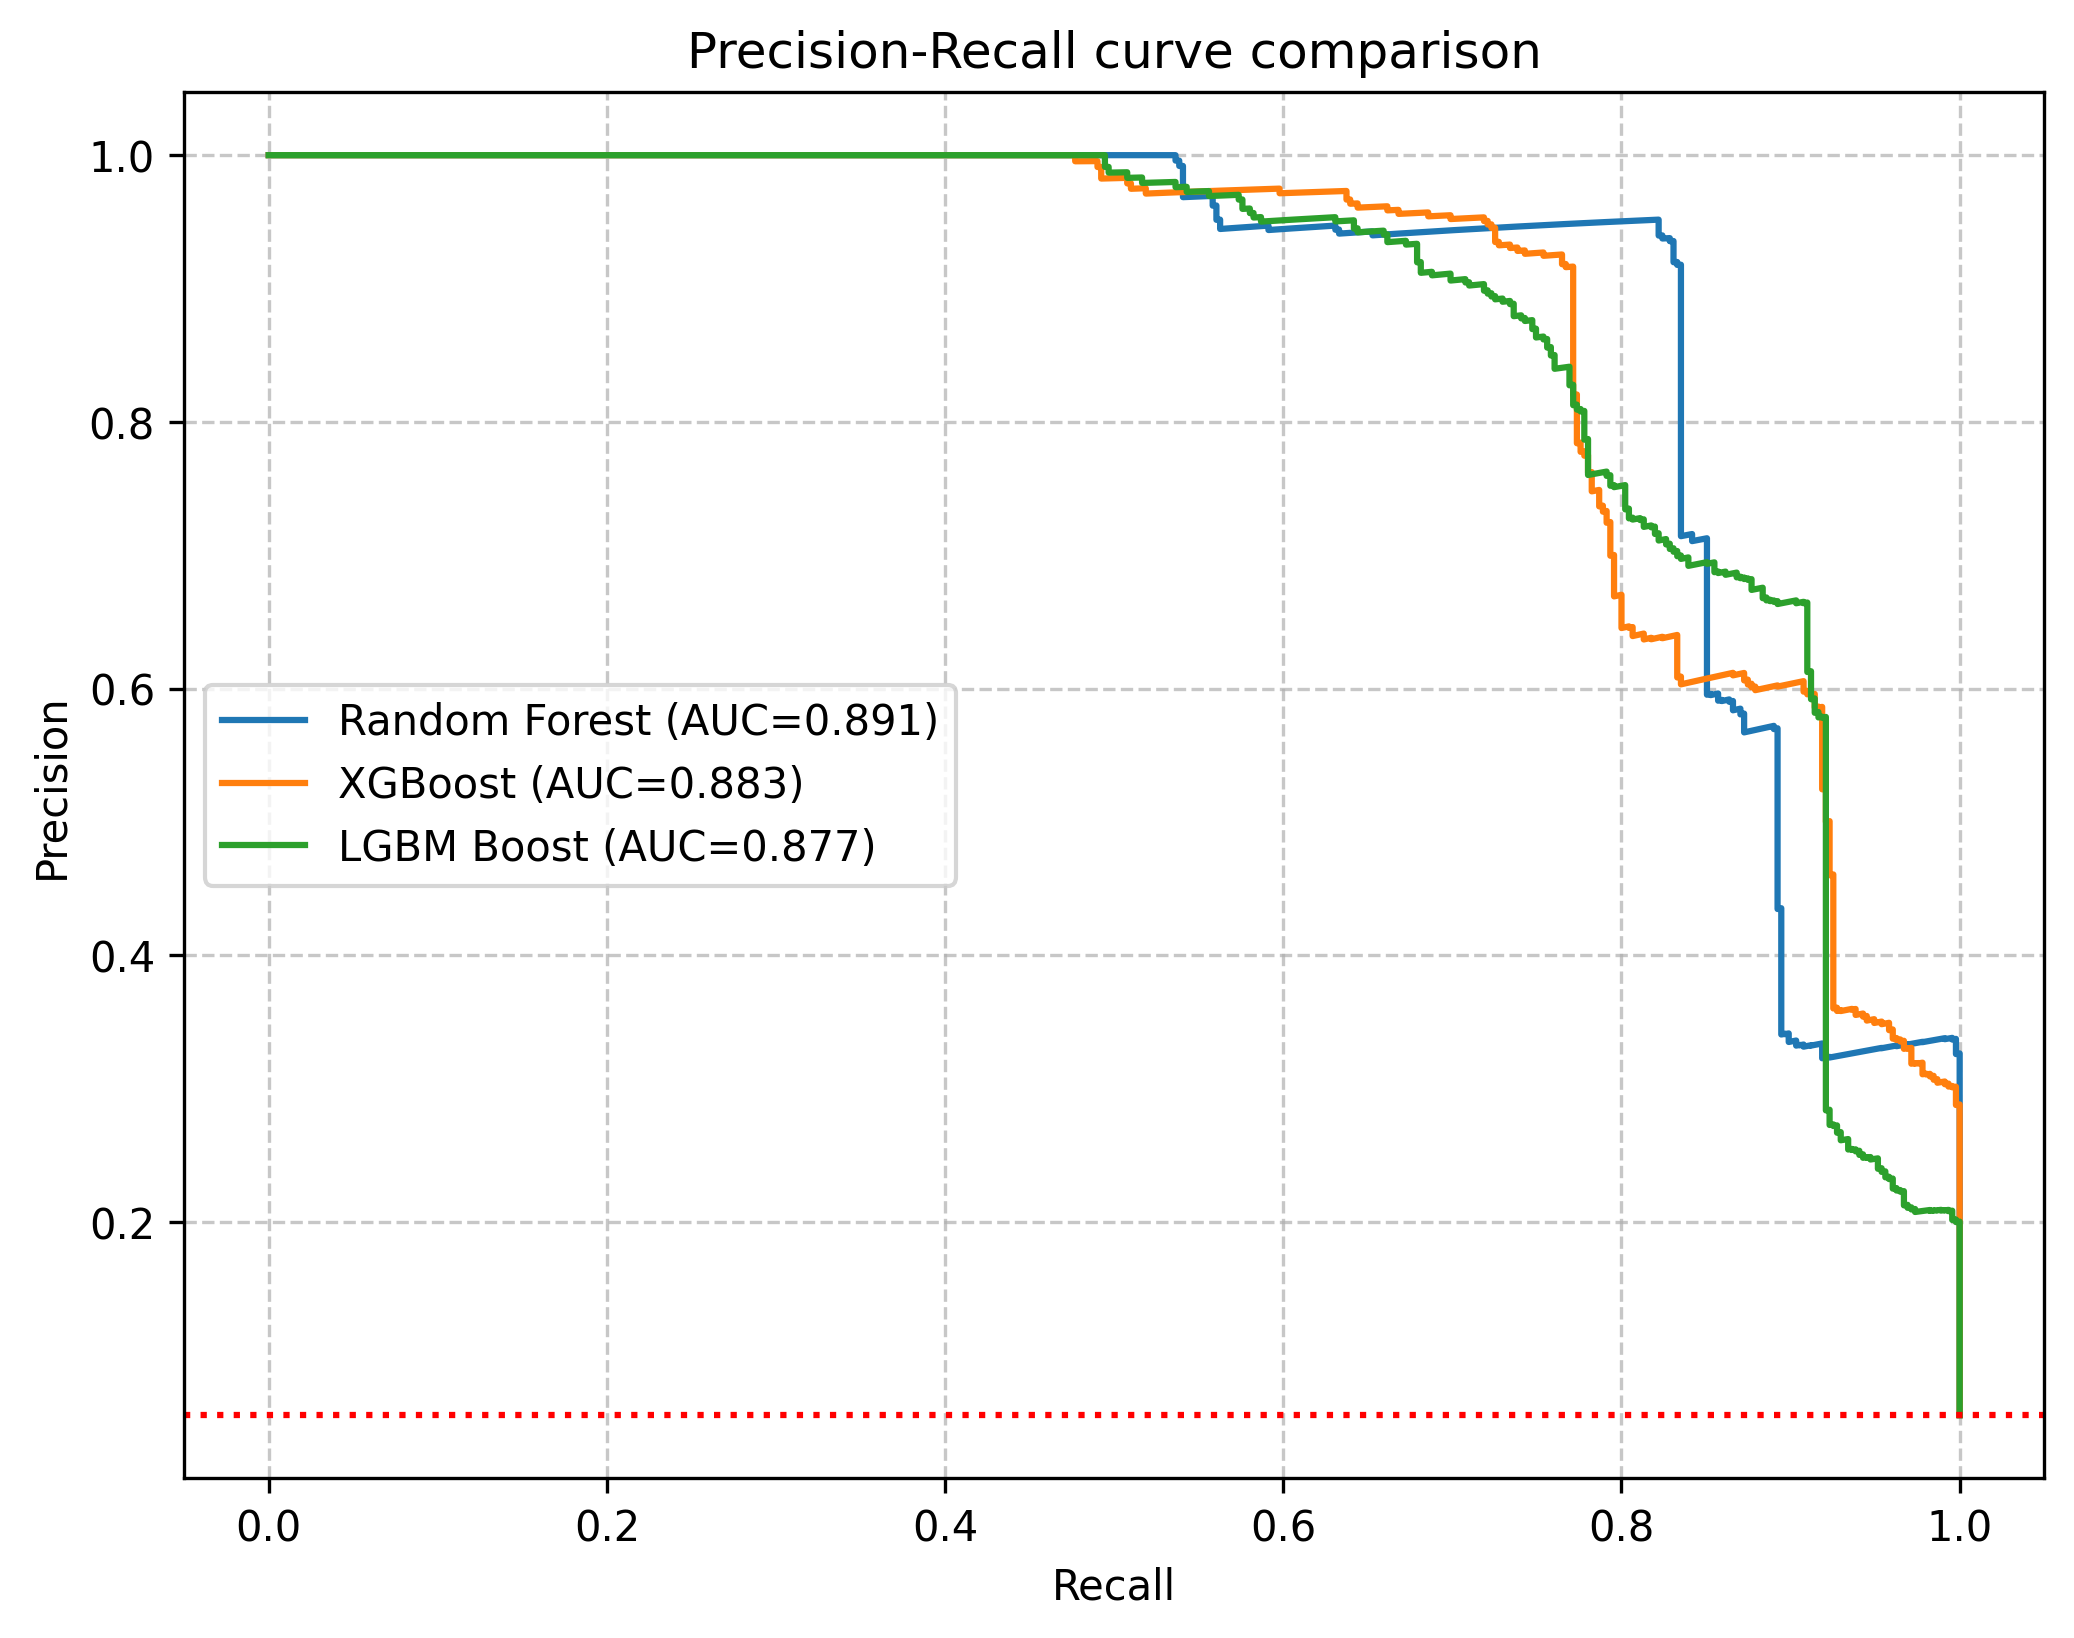

In [ ]:
#plot pr-auc
plot_pr_curves([results, results_xgb, results_lgbm])

## Imbalance handling comparison

In [ ]:

#LGBMClassifier SMOTE pipeline
smote_pipe = ImbPipeline([
    ('preprocessor', preprocess_pipeline),
    ('smote', SMOTE(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42))
])

search_smote_lgbm = RandomizedSearchCV(
    smote_pipe,
    lgbm_param_dist,
    n_iter=20,
    scoring='average_precision',
    n_jobs=1,
    cv=5,
    error_score='raise')
search_smote_lgbm.fit(X_train_u, y_train_u)

print("Best CV score = %0.3f:" % search_smote_lgbm.best_score_)
print("Best parameters: ",search_smote_lgbm.best_params_)

#store the best params and best model for later use
LGBM_smote_best_params = search_lgbm.best_params_
LGBM_smote_best_model = search_lgbm.best_estimator_

Best CV score = 1.000:
Best parameters:  {'lgbm__learning_rate': np.float64(0.2901166610263726), 'lgbm__max_depth': 5, 'lgbm__n_estimators': 191, 'lgbm__num_leaves': 37}


In [ ]:
results_lgbm_smote = evaluate_model(X_test_u, y_test_u, LGBM_smote_best_model, 'LGBM - SMOTE')
print(f"f1 score = {results_lgbm_smote['F1-Score']}" )
print(f"PR Auc = {results_lgbm_smote['PR-AUC']}")
print(f"Roc Auc = {results_lgbm_smote['ROC-AUC']} ")
print(f"Precision = {results_lgbm_smote['Precision']}")
print(f"Recall = {results_lgbm_smote['Recall']}")

f1 score = 0.9976905311778291
PR Auc = 0.9999167751932748
Roc Auc = 0.9999922802155212 
Precision = 0.9965397923875432
Recall = 0.9988439306358381


<Figure size 3000x1800 with 0 Axes>

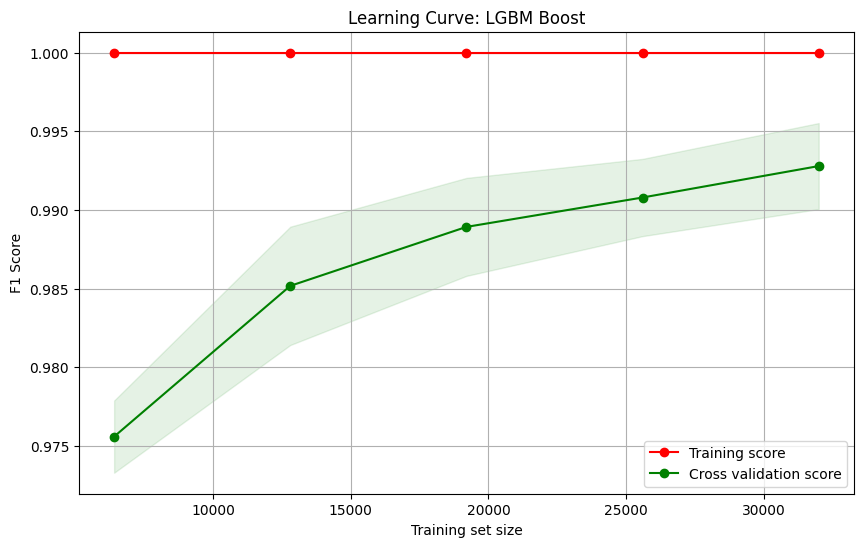

In [ ]:
plot_learning_curve(smote_pipe, X_train_u, y_train_u, "LGBM Boost")

In [ ]:
legitimate_count = y_train.value_counts()[0]
fraud_count = y_train.value_counts()[1]
weight_ratio = legitimate_count / fraud_count

cost_sensitive_lgbm = LGBMClassifier(
    scale_pos_weight=weight_ratio,
    random_state=42
)

cost_sensitive_pipeline = Pipeline([
    ('preprocessor', preprocess_pipeline),
    ('lgbm', cost_sensitive_lgbm)
])

search_cost_sensitive_lgbm = RandomizedSearchCV(
    cost_sensitive_pipeline,
    lgbm_param_dist,
    n_iter=20,
    scoring='average_precision',
    n_jobs=1,
    cv=5,
    error_score='raise')

search_cost_sensitive_lgbm.fit(X_train_u, y_train_u)

print("Best CV score = %0.3f:" % search_cost_sensitive_lgbm.best_score_)
print("Best parameters: ",search_cost_sensitive_lgbm.best_params_)

#store the best params and best model for later use
LGBM_cost_sensitive_best_params = search_cost_sensitive_lgbm.best_params_
LGBM_cost_sensitive_best_model = search_cost_sensitive_lgbm.best_estimator_

Best CV score = 1.000:
Best parameters:  {'lgbm__learning_rate': np.float64(0.20769319115756418), 'lgbm__max_depth': 7, 'lgbm__n_estimators': 120, 'lgbm__num_leaves': 27}


In [ ]:
results_lgbm_cost_sensitive = evaluate_model(X_test_u, y_test_u, LGBM_cost_sensitive_best_model, 'LGBM - cost sensitive')
print(f"f1 score = {results_lgbm_cost_sensitive['F1-Score']}" )
print(f"PR Auc = {results_lgbm_cost_sensitive['PR-AUC']}")
print(f"Roc Auc = {results_lgbm_cost_sensitive['ROC-AUC']} ")
print(f"Precision = {results_lgbm_cost_sensitive['Precision']}")
print(f"Recall = {results_lgbm_cost_sensitive['Recall']}")

f1 score = 0.9959607616849394
PR Auc = 0.9998292956324457
Roc Auc = 0.9999845604310424 
Precision = 0.9942396313364056
Recall = 0.9976878612716763


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


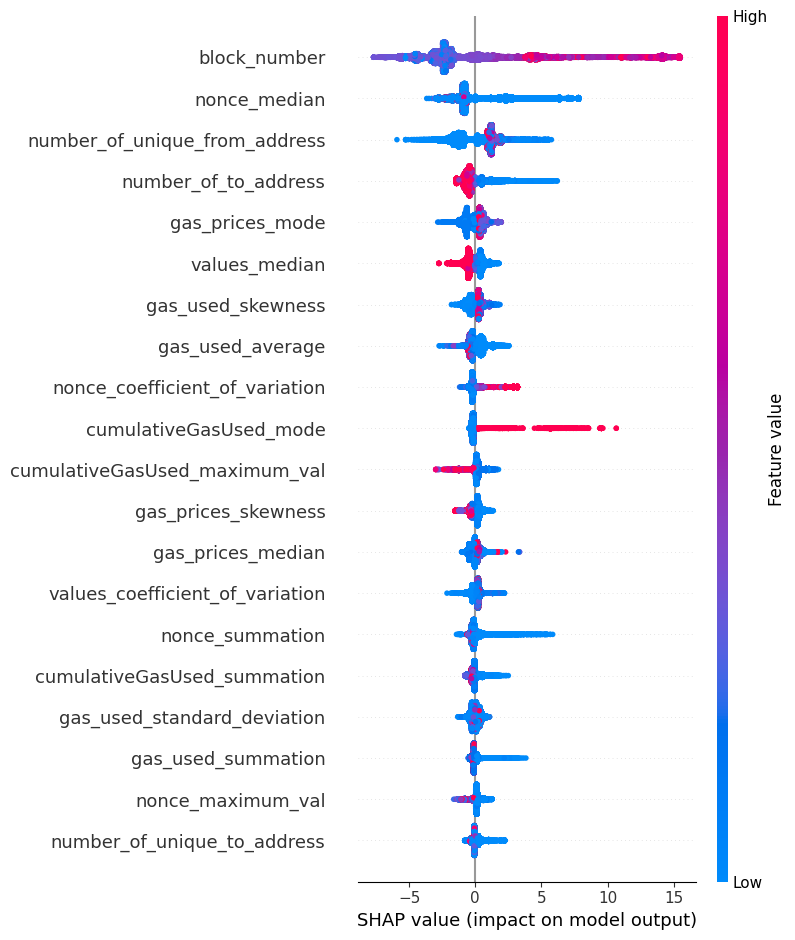

In [ ]:
#Transform training data so SHAP sees what the model sees
X_train_transformed = lgbm_pipe.named_steps['preprocess'].transform(X_train)

best_pipeline = search_lgbm.best_estimator_

best_booster = best_pipeline.named_steps['lgbm'].booster_
#fit the explainer on the transformed data
explainer = shap.TreeExplainer(best_booster)
shap_values = explainer.shap_values(X_train_transformed)

shap.summary_plot(shap_values, X_train_transformed)

In [ ]:
#Calculate mean absolute SHAP value for every column
importance_df = pd.DataFrame({
    'feature': X_train_transformed.columns,
    'importance': np.abs(shap_values).mean(0)
}).sort_values(by='importance', ascending=False)

print(importance_df)

print("Least important features:")
print(importance_df.tail(10))

                          feature  importance
34                   block_number    3.535185
41                   nonce_median    1.583671
48  number_of_unique_from_address    1.323054
29           number_of_to_address    0.716107
42                gas_prices_mode    0.490460
..                            ...         ...
55          token_transfer_amount    0.000000
62           gas_used_range_value    0.000000
72              length_to_address    0.000000
74            event_activity_flag    0.000000
75     from_is_same_as_to_address    0.000000

[76 rows x 2 columns]
Least important features:
                       feature  importance
1            nonce_minimum_val         0.0
3              values_variance         0.0
40      number_of_from_address         0.0
39             num_transaction         0.0
35         gas_prices_variance         0.0
55       token_transfer_amount         0.0
62        gas_used_range_value         0.0
72           length_to_address         0.0
74         e

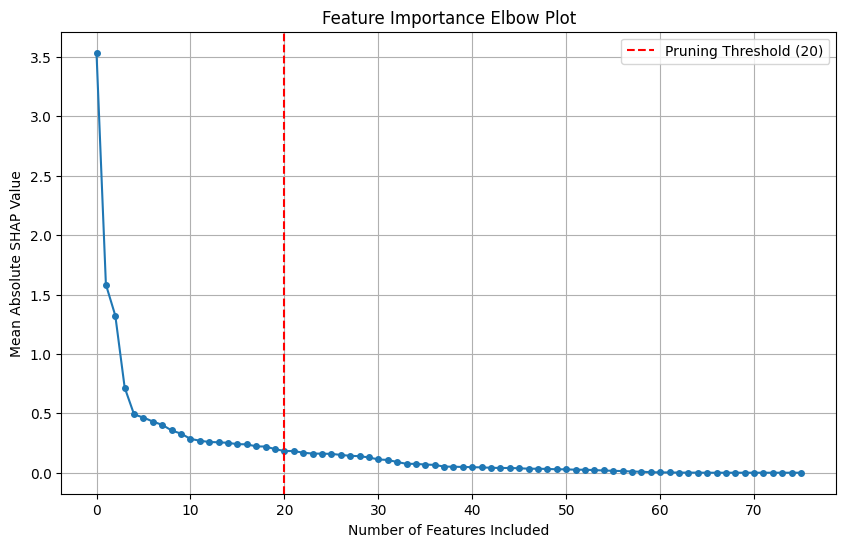

In [ ]:

#Sort values for the plot
df_sorted = importance_df.sort_values(by='importance', ascending=False).reset_index(drop=True)

#Plot the importance values
plt.figure(figsize=(10, 6))
plt.plot(df_sorted.index, df_sorted['importance'], marker='o', linestyle='-', markersize=4)

#Add labels and title
plt.title('Feature Importance Elbow Plot')
plt.xlabel('Number of Features Included')
plt.ylabel('Mean Absolute SHAP Value')
plt.grid(True)

plt.axvline(x=20, color='r', linestyle='--', label='Pruning Threshold (20)')
plt.legend()

plt.show()

In [ ]:

importance_summary = importance_df.copy()

threshold = 0.015
importance_summary['is_near_zero'] = importance_summary['importance'] < threshold

total_features = len(importance_summary)
zero_count = importance_summary['is_near_zero'].sum()

print(f"Total Features: {total_features}")
print(f"Features with near-zero importance (< {threshold}): {zero_count}")
print("\nBottom 20 features (importance values):")
print(importance_summary.tail(20))


Total Features: 76
Features with near-zero importance (< 0.015): 20

Bottom 20 features (importance values):
                       feature  importance  is_near_zero
52                  error_rate    0.014070          True
51               gas_used_mode    0.010049          True
73                    chain_id    0.008322          True
20         cumulative_gas_used    0.004637          True
23   values_standard_deviation    0.002813          True
36           gas_used_variance    0.002450          True
49          values_maximum_val    0.000939          True
5                        value    0.000826          True
66                    gas_used    0.000653          True
4         gas_used_minimum_val    0.000000          True
1            nonce_minimum_val    0.000000          True
3              values_variance    0.000000          True
40      number_of_from_address    0.000000          True
39             num_transaction    0.000000          True
35         gas_prices_variance    0.

In [ ]:
features_to_drop = importance_summary[importance_summary['is_near_zero']]['feature'].tolist()

print(f"Number of features to drop: {len(features_to_drop)}")
print("Features to be dropped:", features_to_drop)

Number of features to drop: 20
Features to be dropped: ['error_rate', 'gas_used_mode', 'chain_id', 'cumulative_gas_used', 'values_standard_deviation', 'gas_used_variance', 'values_maximum_val', 'value', 'gas_used', 'gas_used_minimum_val', 'nonce_minimum_val', 'values_variance', 'number_of_from_address', 'num_transaction', 'gas_prices_variance', 'token_transfer_amount', 'gas_used_range_value', 'length_to_address', 'event_activity_flag', 'from_is_same_as_to_address']


In [ ]:
data_preparation.update_features(features_to_drop)

X_train_s, X_test_s, y_train_s, y_test_s = data_ingestion.get_processed_data(dataset_path)

X_train_s.shape

(40000, 56)

In [ ]:
preprocess_pipeline = data_preparation.generate_preprocessing_pipeline()

#LightGBM pipeline
lgbm_pipe = Pipeline(steps=[
    ('preprocess', preprocess_pipeline),
    ('lgbm', LGBMClassifier(verbose=-1))
])


preprocess_pipeline.fit_transform(X_train_s)

#LightGBM grid
lgbm_param_dist = {
    'lgbm__n_estimators': randint(50, 200),
    'lgbm__max_depth': randint(3, 10),
    'lgbm__learning_rate': uniform(0.01, 0.3),
    'lgbm__num_leaves': randint(20, 50)
}

search_lgbm = RandomizedSearchCV(
    lgbm_pipe,
    lgbm_param_dist,
    n_iter=20,
    scoring='average_precision',
    n_jobs=1,
    cv=5,
    error_score='raise')

search_lgbm.fit(X_train_s, y_train_s)

print("Best CV score = %0.3f:" % search_lgbm.best_score_)
print("Best parameters: ", search_lgbm.best_params_)

#store the best params and best model for later use
LGBM_best_params = search_lgbm.best_params_
LGBM_best_model = search_lgbm.best_estimator_

Best CV score = 1.000:
Best parameters:  {'lgbm__learning_rate': np.float64(0.30600728994623927), 'lgbm__max_depth': 6, 'lgbm__n_estimators': 103, 'lgbm__num_leaves': 20}


In [ ]:
results_lgbm_smote = evaluate_model(X_test_s, y_test_s, LGBM_best_model, 'LGBM - SHAP')
print(f"f1 score = {results_lgbm_smote['F1-Score']}")
print(f"PR Auc = {results_lgbm_smote['PR-AUC']}")
print(f"Roc Auc = {results_lgbm_smote['ROC-AUC']} ")
print(f"Precision = {results_lgbm_smote['Precision']}")
print(f"Recall = {results_lgbm_smote['Recall']}")

f1 score = 0.9976878612716763
PR Auc = 0.9998870127802925
Roc Auc = 0.9999894960309551 
Precision = 0.9976878612716763
Recall = 0.9976878612716763


<Figure size 3000x1800 with 0 Axes>

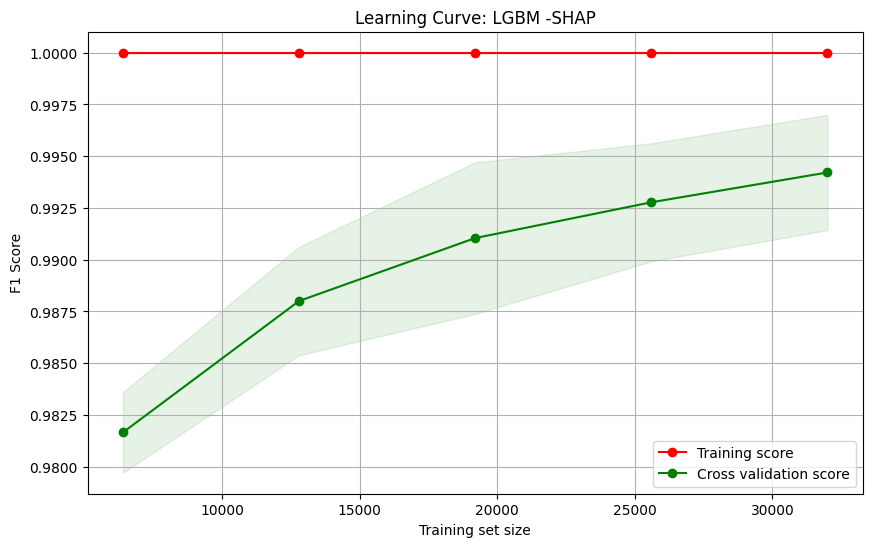

In [ ]:
plot_learning_curve( LGBM_best_model, X_train_s, y_train_s, "LGBM -SHAP")